# Sprint 3: SOTA Upgrade (Memory Efficient Pipeline)

Notebook ini mengimplementasikan perbaikan besar-besaran (Sprint 3) untuk menyamakan performa dengan project CNN-LSTM AE.

## Key Improvements:
1. **Preprocessing Baru:** MinMax Scaler (0-1) yang bersih, fit hanya pada Benign Train.
2. **Clipping:** Menangani outlier ekstrim di data Test dengan clipping ke [0, 1].
3. **Memory Efficient:** Menggunakan `tf.data.Dataset` generator untuk streaming data (anti-OOM).
4. **Modular:** Menggunakan script terpisah untuk preprocessing yang konsisten.

In [1]:
# @title Colab Bootstrap (with Drive Persistence)
# Jalankan cell ini jika di Google Colab untuk setup environment
from pathlib import Path
import os
import subprocess
import sys
import shutil

COLAB_BOOTSTRAP_ENABLE = True
COLAB_REPO_URL = "https://github.com/akwancakra/nids-cnn-lstm-autoencoder.git"
COLAB_BRANCH = "feat/sprint3-sota-upgrade"
COLAB_REPO_DIR = Path("/content/nids-cnn-lstm-autoencoder")

# Drive Persistence Config
COLAB_DRIVE_MOUNT = Path("/content/drive")
COLAB_PROJECT_DRIVE_ROOT = COLAB_DRIVE_MOUNT / "MyDrive/nids-cnn-lstm-autoencoder"

def _is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _run_shell(cmd: list[str], cwd: Path | None = None) -> None:
    print(f"[CMD] {' '.join(cmd)}")
    subprocess.run(cmd, cwd=str(cwd) if cwd else None, check=True)

def _ensure_symlink_dir(repo_path: Path, drive_target: Path) -> None:
    """Symlink repo folder to drive folder for persistence."""
    drive_target.mkdir(parents=True, exist_ok=True)

    if repo_path.is_symlink():
        if repo_path.resolve() == drive_target.resolve():
            print(f"[INFO] Symlink OK: {repo_path} -> {drive_target}")
            return
        repo_path.unlink()
    elif repo_path.exists():
        if any(repo_path.iterdir()):
            print(f"[WARN] Folder exists and not empty: {repo_path}. Skipping link.")
            return
        repo_path.rmdir()

    repo_path.parent.mkdir(parents=True, exist_ok=True)
    os.symlink(str(drive_target), str(repo_path), target_is_directory=True)
    print(f"[INFO] Symlink created: {repo_path} -> {drive_target}")

if _is_colab_runtime() and COLAB_BOOTSTRAP_ENABLE:
    from google.colab import drive
    drive.mount(str(COLAB_DRIVE_MOUNT))

    if not COLAB_REPO_DIR.exists():
        _run_shell(["git", "clone", "-b", COLAB_BRANCH, COLAB_REPO_URL, str(COLAB_REPO_DIR)])
    else:
        _run_shell(["git", "fetch", "--all"], cwd=COLAB_REPO_DIR)
        _run_shell(["git", "checkout", COLAB_BRANCH], cwd=COLAB_REPO_DIR)
        _run_shell(["git", "pull", "origin", COLAB_BRANCH], cwd=COLAB_REPO_DIR)

    # PERSISTENCE: Link Sprint 3 Data & Models to Drive
    # 1. Processed Data
    _ensure_symlink_dir(
        COLAB_REPO_DIR / "data/research/sprint3_upgrade/processed",
        COLAB_PROJECT_DRIVE_ROOT / "data/research/sprint3_upgrade/processed"
    )
    # 2. Models & Results
    _ensure_symlink_dir(
        COLAB_REPO_DIR / "research/sprint3_upgrade/models",
        COLAB_PROJECT_DRIVE_ROOT / "research/sprint3_upgrade/models"
    )
    _ensure_symlink_dir(
        COLAB_REPO_DIR / "research/sprint3_upgrade/results",
        COLAB_PROJECT_DRIVE_ROOT / "research/sprint3_upgrade/results"
    )

    # Set Working Directory
    os.chdir(COLAB_REPO_DIR)
    print(f"[INFO] Working Directory set to: {os.getcwd()}")
else:
    print("Not in Colab or Bootstrap disabled.")


Mounted at /content/drive
[CMD] git clone -b feat/sprint3-sota-upgrade https://github.com/akwancakra/nids-cnn-lstm-autoencoder.git /content/nids-cnn-lstm-autoencoder
[INFO] Symlink created: /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed -> /content/drive/MyDrive/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed
[INFO] Symlink created: /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/models -> /content/drive/MyDrive/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/models
[INFO] Symlink created: /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results -> /content/drive/MyDrive/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results
[INFO] Working Directory set to: /content/nids-cnn-lstm-autoencoder


In [2]:
# Setup Project Root & Imports
import os
import sys
from pathlib import Path
import yaml
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import glob
from tqdm.notebook import tqdm

# Deteksi Project Root (Fallback mechanism)
try:
    # Jika di Colab dan sudah chdir, getcwd() adalah root
    PROJECT_ROOT = Path(os.getcwd()).resolve()

    # Validasi sederhana: cek folder research ada atau tidak
    if not (PROJECT_ROOT / "research").exists():
        # Coba naik satu level (jika notebook dijalankan lokal dari folder notebooks/)
        if (PROJECT_ROOT.parent / "research").exists():
            PROJECT_ROOT = PROJECT_ROOT.parent
        else:
            # Fallback hardcoded untuk Colab jika chdir gagal
            PROJECT_ROOT = Path("/content/nids-cnn-lstm-autoencoder")
except Exception:
    PROJECT_ROOT = Path(".")

print(f"Project Root: {PROJECT_ROOT}")
sys.path.append(str(PROJECT_ROOT))

# Load Config Sprint 3
config_path = PROJECT_ROOT / "research/sprint3_upgrade/config/experiment_v1.yaml"

if config_path.exists():
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print(f"Experiment: {config['experiment_name']}")
    print(f"Config Loaded: {config_path}")
else:
    print(f"ERROR: Config not found at {config_path}")
    print("Make sure you have cloned the repo and switched to the correct branch.")


Project Root: /content/nids-cnn-lstm-autoencoder
Experiment: sprint3_sota_upgrade_v1
Config Loaded: /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/config/experiment_v1.yaml


### 1.1 EDA Data Raw (Opsional)
Inspeksi singkat file CSV mentah untuk melihat kolom, missing values, dan distribusi label.

In [3]:
import pandas as pd
from pathlib import Path
import glob
import os
from IPython.display import display

def pick_first_existing(paths):
    for p in paths:
        if p is None:
            continue
        p = Path(p)
        if p.exists():
            return p
    return None

raw_train_dir = None
raw_test_dir = None

if 'raw_train' in locals() and 'raw_test' in locals():
    raw_train_dir = Path(raw_train)
    raw_test_dir = Path(raw_test)

if raw_train_dir is None and 'config' in locals() and 'paths' in config:
    if 'raw_train' in config['paths']:
        raw_train_dir = PROJECT_ROOT / config['paths']['raw_train']
    if 'raw_test' in config['paths']:
        raw_test_dir = PROJECT_ROOT / config['paths']['raw_test']

if raw_train_dir is None:
    raw_train_dir = pick_first_existing([
        "/content/drive/MyDrive/nids-data/raw/CIC-IDS2017",
        PROJECT_ROOT / "data" / "raw" / "CIC-IDS2017"
    ])
if raw_test_dir is None:
    raw_test_dir = pick_first_existing([
        "/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018",
        PROJECT_ROOT / "data" / "raw" / "CSE-CIC-IDS2018"
    ])

def inspect_raw_dir(raw_dir, name):
    print(f"\n--- RAW {name} ---")
    if raw_dir is None or not Path(raw_dir).exists():
        print("Raw folder not found.")
        return
    raw_dir = Path(raw_dir)
    files = sorted(glob.glob(str(raw_dir / "*.csv")))
    if not files:
        files = sorted(glob.glob(str(raw_dir / "**" / "*.csv"), recursive=True))
    if not files:
        print(f"No CSV files found at {raw_dir}")
        return
    print(f"Folder: {raw_dir}")
    print(f"Files: {len(files)}")
    sample_file = files[0]
    print(f"Sample file: {os.path.basename(sample_file)}")
    try:
        df = pd.read_csv(sample_file, nrows=20000)
    except Exception:
        df = pd.read_csv(sample_file, nrows=5000, engine="python")
    print(f"Shape: {df.shape}")
    display(df.head(5))
    print("Missing (top 10):")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    label_col = "Label" if "Label" in df.columns else ("label" if "label" in df.columns else None)
    if label_col:
        print(f"Label distribution ({label_col}):")
        print(df[label_col].value_counts().head(20))

inspect_raw_dir(raw_train_dir, "CIC-IDS2017 (Train)")
inspect_raw_dir(raw_test_dir, "CSE-CIC-IDS2018 (Test)")



--- RAW CIC-IDS2017 (Train) ---
Raw folder not found.

--- RAW CSE-CIC-IDS2018 (Test) ---
Raw folder not found.


### 1.2 Ringkasan Label CIC vs CSE (Raw)
Menampilkan total benign/attack dan distribusi per serangan dari dataset mentah.

In [4]:
import pandas as pd
from pathlib import Path
import glob
from IPython.display import display

def find_label_column(sample_file):
    cols = pd.read_csv(sample_file, nrows=0, low_memory=False).columns.tolist()
    clean_map = {str(c).strip().lower(): c for c in cols}
    return clean_map.get("label")

def count_labels_in_dir(raw_dir, dataset_name, chunksize=200000):
    print(f"\n--- LABEL SUMMARY {dataset_name} ---")
    if raw_dir is None or not Path(raw_dir).exists():
        print("Raw folder not found.")
        return None, None
    raw_dir = Path(raw_dir)
    files = sorted(glob.glob(str(raw_dir / "*.csv")))
    if not files:
        files = sorted(glob.glob(str(raw_dir / "**" / "*.csv"), recursive=True))
    if not files:
        print(f"No CSV files found at {raw_dir}")
        return None, None
    label_col = find_label_column(files[0])
    if not label_col:
        print("Label column not found.")
        return None, None
    counts = {}
    for f in files:
        for chunk in pd.read_csv(f, usecols=[label_col], chunksize=chunksize, low_memory=False):
            vc = chunk[label_col].fillna("UNKNOWN").astype(str).value_counts()
            for k, v in vc.items():
                counts[k] = counts.get(k, 0) + int(v)
    if not counts:
        print("No label counts found.")
        return None, None
    total = int(sum(counts.values()))
    benign_total = int(sum(v for k, v in counts.items() if str(k).strip().upper() == "BENIGN"))
    attack_total = int(total - benign_total)
    overall_df = pd.DataFrame([
        {"dataset": dataset_name, "benign": benign_total, "attack": attack_total, "total": total}
    ])
    attack_rows = [
        {"dataset": dataset_name, "label": k, "count": int(v)}
        for k, v in counts.items()
        if str(k).strip().upper() != "BENIGN"
    ]
    attack_df = (
        pd.DataFrame(attack_rows).sort_values(by="count", ascending=False)
        if attack_rows
        else pd.DataFrame(columns=["dataset", "label", "count"])
    )
    display(overall_df)
    display(attack_df)
    return overall_df, attack_df

count_labels_in_dir(raw_train_dir, "CIC-IDS2017 (Train)")
count_labels_in_dir(raw_test_dir, "CSE-CIC-IDS2018 (Test)")



--- LABEL SUMMARY CIC-IDS2017 (Train) ---
Raw folder not found.

--- LABEL SUMMARY CSE-CIC-IDS2018 (Test) ---
Raw folder not found.


(None, None)

## 1. Data Inspection (EDA)
Menganalisis distribusi data mentah (RAW) atau processed yang tersedia.
Cell ini akan mencoba mendeteksi data secara otomatis di path standar.

[INFO] Inspecting data at: /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed

--- Analyzing Train Set (Benign Expected) ---
Sample File: train_shard_0.npz
Keys: ['X', 'y']
  X: shape=(19536, 10, 32), dtype=float64
  y: shape=(19536,), dtype=float64
Scanning 8 files (sample) for label distribution...


Scanning Train Set (Benign Expected):   0%|          | 0/8 [00:00<?, ?it/s]

Scanned Samples: 454253
Estimated Total Samples: 454253
Label Distribution (Scanned): {np.float64(0.0): 454253}


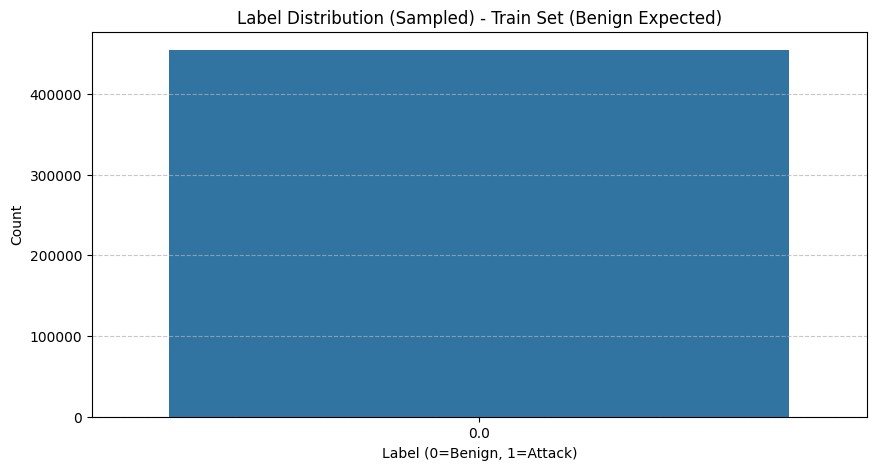


--- Analyzing Test Set (Mixed Expected) ---
Sample File: test_shard_0.npz
Keys: ['X', 'y']
  X: shape=(208949, 10, 32), dtype=float64
  y: shape=(208949,), dtype=int64
Scanning 3 files (sample) for label distribution...


Scanning Test Set (Mixed Expected):   0%|          | 0/3 [00:00<?, ?it/s]

Scanned Samples: 626770
Estimated Total Samples: 626770
Label Distribution (Scanned): {np.int64(0): 342591, np.int64(1): 284179}


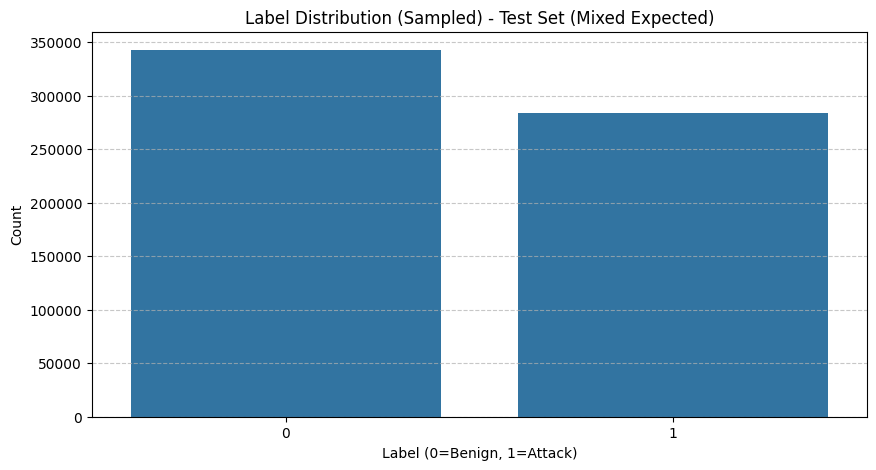

In [5]:
# @title Data Inspection & Class Distribution
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm
import numpy as np
import os
import glob
from pathlib import Path

# Default values to prevent NameError
train_files = []
test_files = []

# --- AUTO DETECT DATA PATHS ---
# Coba deteksi path data processed (hasil run sebelumnya)
try:
    base_processed = None
    if 'config' in locals() and 'paths' in config:
        if 'processed_data' in config['paths']:
            base_processed = PROJECT_ROOT / config['paths']['processed_data']
        elif 'train_data' in config['paths']:
            base_processed = Path(config['paths']['train_data']).parent

    if base_processed is None:
        candidates = [
            Path("data/processed"),
            Path("../data/processed"),
            Path("/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed"),
            Path("/content/nids-mscnn-bilstm-autoencoder/data/processed")
        ]
        for p in candidates:
            if p.exists():
                base_processed = p
                break

    if base_processed:
        print(f"[INFO] Inspecting data at: {base_processed}")
        train_files = sorted(glob.glob(str(base_processed / "train" / "*.npz")))
        test_files = sorted(glob.glob(str(base_processed / "test" / "*.npz")))

        if not train_files:
             train_files = sorted(glob.glob(str(base_processed / "**" / "train" / "*.npz"), recursive=True))
        if not test_files:
             test_files = sorted(glob.glob(str(base_processed / "**" / "test" / "*.npz"), recursive=True))
    else:
        print("[WARN] Processed data directory not found yet. Run preprocessing first or check paths.")

except Exception as e:
    print(f"[ERROR] Path detection failed: {e}")

def analyze_distribution(files, set_name="Dataset"):
    print(f"\n--- Analyzing {set_name} ---")
    if not files:
        print("No files found.")
        return

    try:
        with np.load(files[0], allow_pickle=True) as data:
            print(f"Sample File: {os.path.basename(files[0])}")
            print(f"Keys: {list(data.keys())}")
            for k in data.keys():
                obj = data[k]
                print(f"  {k}: shape={obj.shape}, dtype={obj.dtype}")
    except Exception as e:
        print(f"Error reading sample file: {e}")
        return

    label_counts = Counter()
    total_samples = 0

    scan_limit = min(len(files), 100)
    print(f"Scanning {scan_limit} files (sample) for label distribution...")

    for f in tqdm(files[:scan_limit], desc=f"Scanning {set_name}"):
        try:
            with np.load(f, allow_pickle=True) as data:
                y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)
                if y is not None:
                    if len(y.shape) > 0:
                        label_counts.update(y)
                    else:
                        label_counts[y.item()] += 1
                    total_samples += len(y) if len(y.shape) > 0 else 1
        except: pass

    scale_factor = len(files) / scan_limit
    estimated_total = int(total_samples * scale_factor)

    print(f"Scanned Samples: {total_samples}")
    print(f"Estimated Total Samples: {estimated_total}")
    print(f"Label Distribution (Scanned): {dict(label_counts)}")

    if label_counts:
        plt.figure(figsize=(10, 5))
        keys = list(label_counts.keys())
        vals = list(label_counts.values())
        sns.barplot(x=keys, y=vals)
        plt.title(f"Label Distribution (Sampled) - {set_name}")
        plt.xlabel("Label (0=Benign, 1=Attack)")
        plt.ylabel("Count")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

if train_files:
    analyze_distribution(train_files, "Train Set (Benign Expected)")
else:
    print("Train files not found. (Maybe preprocessing hasn't run yet?)")

if test_files:
    analyze_distribution(test_files, "Test Set (Mixed Expected)")
else:
    print("Test files not found.")


## 1.3 Feature Drift Analysis (Domain Adaptation)
Menganalisis pergeseran distribusi fitur antara CIC-IDS2017 (Source) dan CSE-CIC-IDS2018 (Target).
Fitur dengan drift tinggi (KS Statistic > 0.5) akan didrop untuk meningkatkan generalisasi.

In [6]:
# Run Drift Analysis
import os
from pathlib import Path

output_dir = PROJECT_ROOT / "research/sprint3_upgrade/results"
script_path = PROJECT_ROOT / "research/sprint3_upgrade/scripts/analyze_drift.py"

# Define Raw Paths (Logic copied from Preprocessing cell)
if os.path.exists("/content/drive/MyDrive/nids-data/raw"):
    raw_train = Path("/content/drive/MyDrive/nids-data/raw/CIC-IDS2017")
    raw_test = Path("/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018")
else:
    raw_train = PROJECT_ROOT / config['paths']['raw_train']
    raw_test = PROJECT_ROOT / config['paths']['raw_test']

print(f"Raw Train: {raw_train}")
print(f"Raw Test: {raw_test}")

if raw_train.exists() and raw_test.exists():
    cmd = f'python "{script_path}" --raw_train "{raw_train}" --raw_test "{raw_test}" --output_dir "{output_dir}" --ks_threshold 0.5'
    print(f"Executing: {cmd}")
    !{cmd}
else:
    print("Raw data not found, skipping drift analysis.")


Raw Train: /content/drive/MyDrive/nids-data/raw/CIC-IDS2017
Raw Test: /content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018
Executing: python "/content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/scripts/analyze_drift.py" --raw_train "/content/drive/MyDrive/nids-data/raw/CIC-IDS2017" --raw_test "/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018" --output_dir "/content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results" --ks_threshold 0.5
Loading Source Data (2017)...
Loading /content/drive/MyDrive/nids-data/raw/CIC-IDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Loading /content/drive/MyDrive/nids-data/raw/CIC-IDS2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Loading /content/drive/MyDrive/nids-data/raw/CIC-IDS2017/Friday-WorkingHours-Morning.pcap_ISCX.csv...
Loading Target Data (2018)...
Loading /content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018/02-14-2018.csv...
Loading /content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018/02-15-2018.csv...

## 2. Preprocessing (SOTA Style with Domain Adaptation)
Jalankan script preprocessing baru yang menerapkan MinMax(0-1), Clipping, dan **Drop High Drift Features**.

In [7]:
# Run Preprocessing Script (If data not exists)
processed_dir = PROJECT_ROOT / config['paths']['processed_data']
train_dir = processed_dir / "train"
test_dir = processed_dir / "test"

# FORCE RE-RUN PREPROCESSING TO FIX LABEL BUG
RUN_PREPROCESSING = True # Set to True because we are dropping features (Drift Analysis), so we MUST regenerate data.

# --- AUTO DETECT & REUSE LOGIC ---
# Check if processed data already exists (locally or via symlink)
if train_dir.exists() and any(train_dir.iterdir()):
    print("[INFO] Processed data found! But RUN_PREPROCESSING is set to True to apply Drift Analysis changes.")
    # RUN_PREPROCESSING = False # Disabled to force re-run

# Adjust Raw Paths for Colab Support
if os.path.exists("/content/drive/MyDrive/nids-data/raw"):
    print("[INFO] Colab Drive Raw Data Detected.")
    raw_train = Path("/content/drive/MyDrive/nids-data/raw/CIC-IDS2017")
    raw_test = Path("/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018")
else:
    # Local fallback or repo path
    raw_train = PROJECT_ROOT / config['paths']['raw_train']
    raw_test = PROJECT_ROOT / config['paths']['raw_test']
# -------------------------------------------------

if RUN_PREPROCESSING:
    print("Running Preprocessing Script... (This may take a while)")
    script_path = PROJECT_ROOT / "research/sprint3_upgrade/scripts/preprocess_sota.py"

    # Check raw data
    if not raw_train.exists():
        print(f"Error: Raw train path {raw_train} not found!")
        print("Please check config or mount drive correctly.")
    else:
        # Check for drop list
        drop_list_path = PROJECT_ROOT / "research/sprint3_upgrade/results/high_drift_features.txt"
        drop_arg = ""
        if drop_list_path.exists():
            print(f"Found drop list at {drop_list_path}")
            !cat "{drop_list_path}" # Debug file content
            drop_arg = f'--drop_features "{drop_list_path}"'

        cmd = f'python "{script_path}" --raw_train "{raw_train}" --raw_test "{raw_test}" --raw_test_cic "{raw_train}" --output_dir "{processed_dir}" --seq_len {config["preprocessing"]["sequence_length"]} --stride {config["preprocessing"]["stride"]} --scaler_type {config.get("scaler", "quantile")} {drop_arg}'
        print(f"Executing: {cmd}")
        !{cmd}
else:
    print("Skipping Preprocessing (Data already exists).")
    print(f"Data Location: {processed_dir}")


[INFO] Processed data found! But RUN_PREPROCESSING is set to True to apply Drift Analysis changes.
[INFO] Colab Drive Raw Data Detected.
Running Preprocessing Script... (This may take a while)
Found drop list at /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results/high_drift_features.txt
Executing: python "/content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/scripts/preprocess_sota.py" --raw_train "/content/drive/MyDrive/nids-data/raw/CIC-IDS2017" --raw_test "/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018" --raw_test_cic "/content/drive/MyDrive/nids-data/raw/CIC-IDS2017" --output_dir "/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed" --seq_len 10 --stride 5 --scaler_type quantile --drop_features "/content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results/high_drift_features.txt"
DEBUG: Found drop list file at /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results/high_drift_features.txt
DEBUG: Read 0 columns fr

In [8]:
# @title Verify New Test Set Distribution
import numpy as np
import glob
import os

test_files = sorted(glob.glob(str(test_dir / "*.npz")))
if test_files:
    print(f"Found {len(test_files)} test files. Checking the first one...")
    sample_file = test_files[0]
    with np.load(sample_file, allow_pickle=True) as data:
        y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)
        if y is not None:
            unique, counts = np.unique(y, return_counts=True)
            dist = dict(zip(unique, counts))
            print(f"Label Distribution in {os.path.basename(sample_file)}: {dist}")
            if 0 in dist and 1 in dist:
                print("✅ SUCCESS: Both Benign (0) and Attack (1) are present!")
            else:
                print("❌ ERROR: Missing classes. Check preprocessing logic.")
else:
    print("No test files found. Preprocessing might have failed.")


Found 3 test files. Checking the first one...
Label Distribution in test_shard_0.npz: {np.int64(0): np.int64(132346), np.int64(1): np.int64(76603)}
✅ SUCCESS: Both Benign (0) and Attack (1) are present!


## 2. Verifikasi Data Processed
Memverifikasi kualitas data setelah preprocessing untuk memastikan tidak ada masalah pada distribusi, korelasi, dan label.

### 2.1 Visualisasi Distribusi Fitur
Menganalisis distribusi fitur setelah preprocessing untuk memastikan normalisasi bekerja dengan baik.

Train shape: (50000, 34), Test shape: (50000, 34)


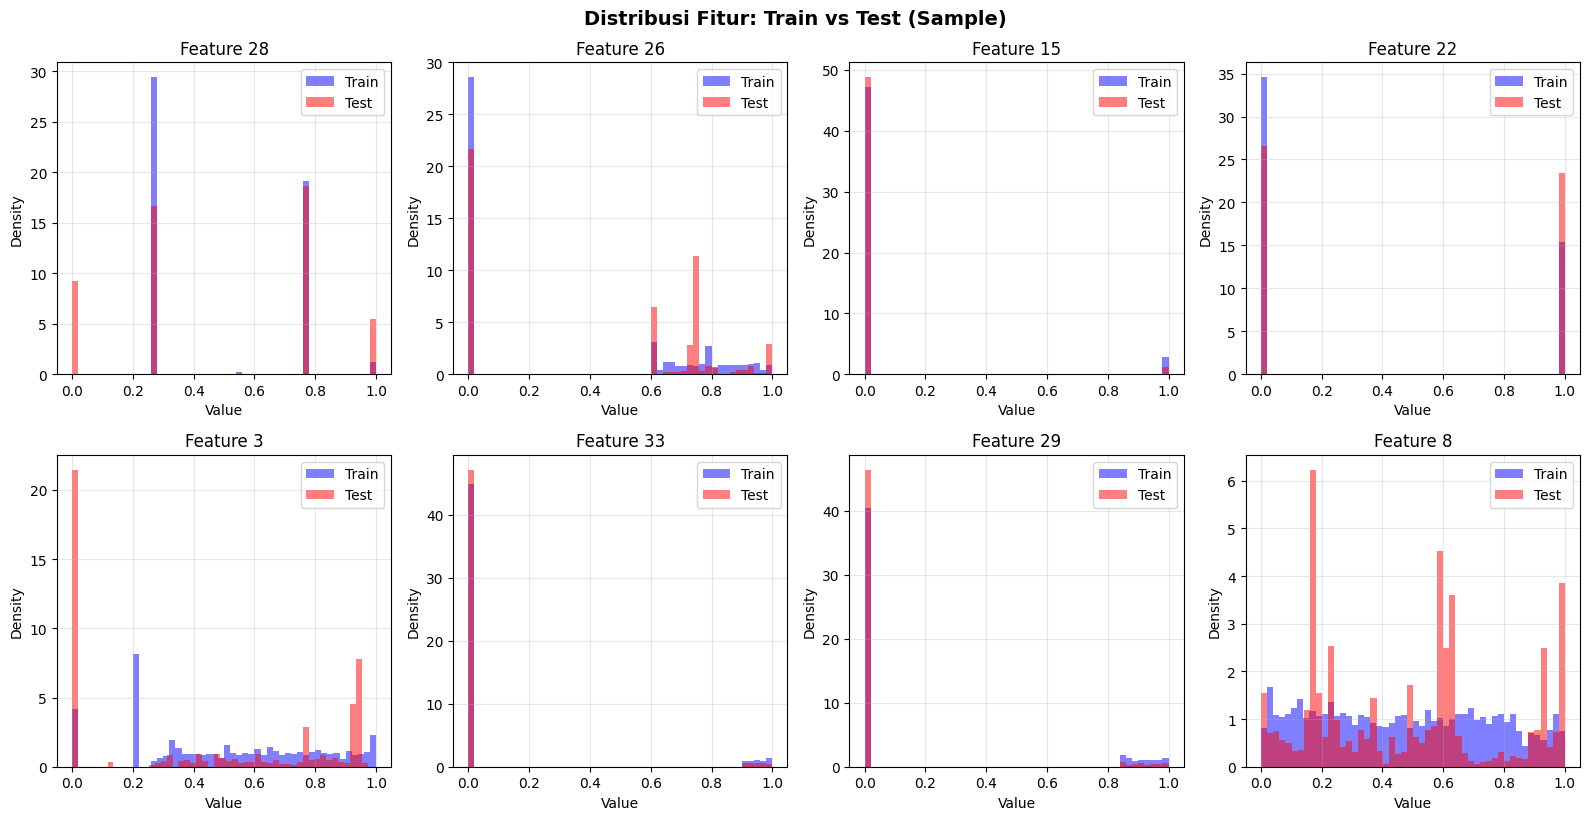


=== Ringkasan Statistik ===
Train - Min: 0.0000, Max: 1.0000, Mean: 0.3673
Test  - Min: 0.0000, Max: 1.0000, Mean: 0.3096

Outliers (di luar [0,1]):
  Train: 0 (0.00%)
  Test: 0 (0.00%)

[OK] Data terdistribusi dengan baik dalam range [0, 1]


In [9]:
# @title Visualisasi Distribusi Fitur (Train vs Test)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path

def load_sample_data(data_dir, n_files=3, n_samples=5000):
    """Load sample data dari direktori untuk analisis distribusi."""
    files = sorted(glob.glob(str(data_dir / "*.npz")))[:n_files]
    if not files:
        print(f"Tidak ada file di {data_dir}")
        return None

    X_list = []
    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                X_batch = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)
                if X_batch is not None:
                    X_list.append(X_batch)
        except Exception as e:
            print(f"Error reading {f}: {e}")

    if X_list:
        X_concat = np.concatenate(X_list, axis=0)
        if len(X_concat) > n_samples:
            indices = np.random.choice(len(X_concat), n_samples, replace=False)
            X_concat = X_concat[indices]
        return X_concat
    return None

# Load data
if 'processed_dir' in locals() and processed_dir.exists():
    train_data = load_sample_data(processed_dir / "train", n_files=3)
    test_data = load_sample_data(processed_dir / "test", n_files=3)

    if train_data is not None and test_data is not None:
        train_flat = train_data.reshape(-1, train_data.shape[-1])
        test_flat = test_data.reshape(-1, test_data.shape[-1])

        print(f"Train shape: {train_flat.shape}, Test shape: {test_flat.shape}")

        n_features_to_plot = 8
        feature_indices = np.random.choice(train_flat.shape[1], n_features_to_plot, replace=False)

        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.flatten()

        for idx, feat_idx in enumerate(feature_indices):
            ax = axes[idx]
            ax.hist(train_flat[:, feat_idx], bins=50, alpha=0.5, label='Train', density=True, color='blue')
            ax.hist(test_flat[:, feat_idx], bins=50, alpha=0.5, label='Test', density=True, color='red')
            ax.set_title(f'Feature {feat_idx}')
            ax.set_xlabel('Value')
            ax.set_ylabel('Density')
            ax.legend()
            ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.suptitle('Distribusi Fitur: Train vs Test (Sample)', y=1.02, fontsize=14, fontweight='bold')
        plt.show()

        print("\n=== Ringkasan Statistik ===")
        print(f"Train - Min: {train_flat.min():.4f}, Max: {train_flat.max():.4f}, Mean: {train_flat.mean():.4f}")
        print(f"Test  - Min: {test_flat.min():.4f}, Max: {test_flat.max():.4f}, Mean: {test_flat.mean():.4f}")

        train_outliers = np.sum((train_flat < 0) | (train_flat > 1))
        test_outliers = np.sum((test_flat < 0) | (test_flat > 1))
        print(f"\nOutliers (di luar [0,1]):")
        print(f"  Train: {train_outliers} ({train_outliers/train_flat.size*100:.2f}%)")
        print(f"  Test: {test_outliers} ({test_outliers/test_flat.size*100:.2f}%)")

        if train_outliers == 0 and test_outliers == 0:
            print("\n[OK] Data terdistribusi dengan baik dalam range [0, 1]")
    else:
        print("[ERROR] Gagal load data untuk visualisasi")
else:
    print("[ERROR] Variable 'processed_dir' tidak ditemukan. Jalankan cell preprocessing terlebih dahulu.")


### 2.2 Correlation Matrix Analysis
Mengidentifikasi fitur yang sangat berkorelasi yang mungkin perlu di-drop.

Menganalisis korelasi fitur pada data training...


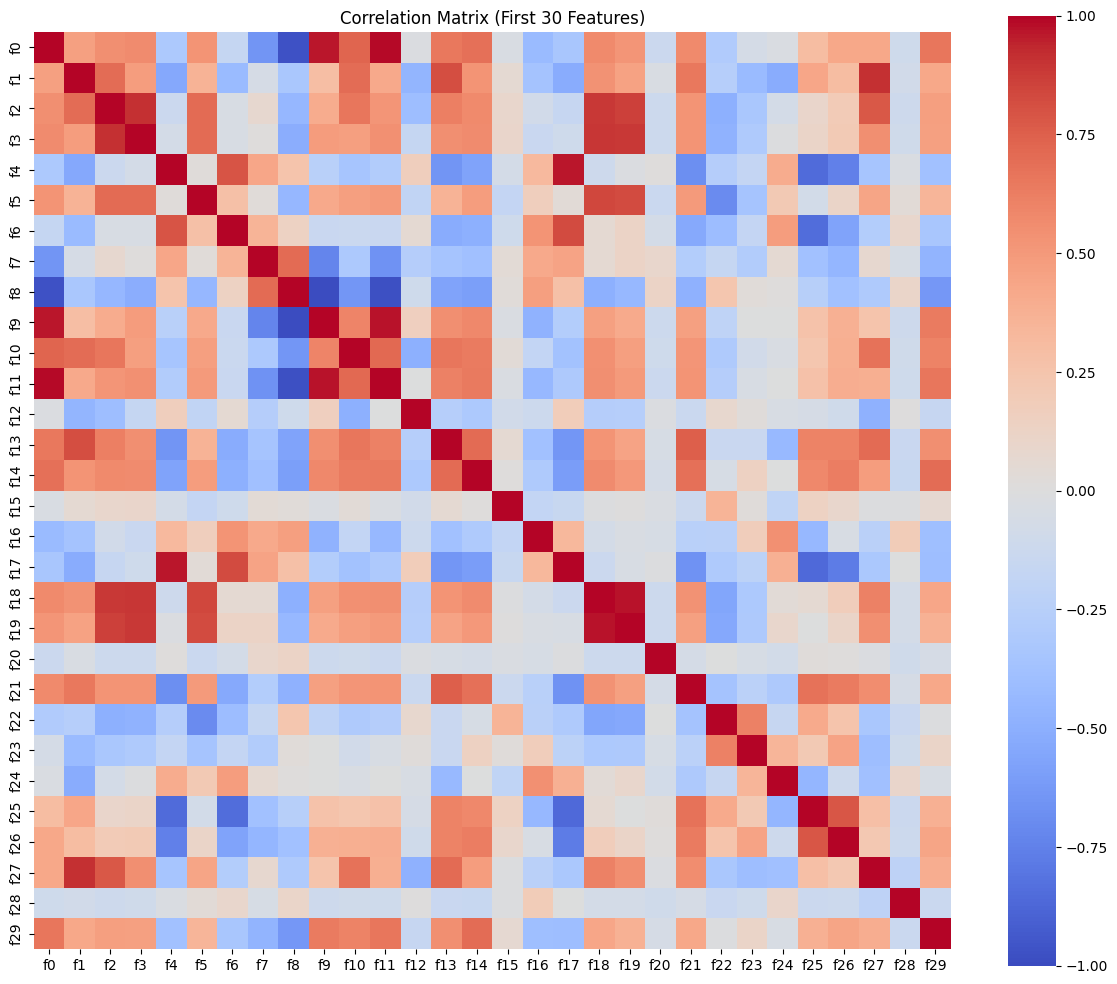


[WARNING] Ditemukan 14 pasangan fitur dengan korelasi > 0.9
   Feature 1 Feature 2  Correlation
10       f29       f31     0.999674
11       f29       f32     0.999063
13       f31       f32     0.998227
6         f8        f9    -0.995056
2         f0       f11     0.991458
7         f8       f11    -0.983785
0         f0        f8    -0.976326
9        f18       f19     0.976112
8         f9       f11     0.972802
5         f4       f17     0.968460
1         f0        f9     0.962970
12       f30       f33     0.912302
3         f1       f27     0.908236
4         f2        f3     0.908050

[RECOMMENDATION] Pertimbangkan untuk drop salah satu fitur dari setiap pasangan.


In [10]:
# @title Correlation Matrix untuk Deteksi Fitur Redundant
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def analyze_correlation(data, threshold=0.9):
    if len(data.shape) == 3:
        data_flat = data.reshape(-1, data.shape[-1])
    else:
        data_flat = data

    if len(data_flat) > 10000:
        indices = np.random.choice(len(data_flat), 10000, replace=False)
        data_flat = data_flat[indices]

    df = pd.DataFrame(data_flat, columns=[f'f{i}' for i in range(data_flat.shape[1])])
    corr_matrix = df.corr()

    n_features = min(30, df.shape[1])
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix.iloc[:n_features, :n_features],
                annot=False, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True)
    plt.title(f'Correlation Matrix (First {n_features} Features)')
    plt.tight_layout()
    plt.show()

    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })

    if high_corr_pairs:
        print(f"\n[WARNING] Ditemukan {len(high_corr_pairs)} pasangan fitur dengan korelasi > {threshold}")
        df_pairs = pd.DataFrame(high_corr_pairs).sort_values(by='Correlation', key=abs, ascending=False)
        print(df_pairs.head(20))
        print(f"\n[RECOMMENDATION] Pertimbangkan untuk drop salah satu fitur dari setiap pasangan.")
    else:
        print(f"\n[OK] Tidak ada pasangan fitur dengan korelasi > {threshold}")

    return corr_matrix

if 'train_data' in locals() and train_data is not None:
    print("Menganalisis korelasi fitur pada data training...")
    corr_matrix = analyze_correlation(train_data, threshold=0.9)
else:
    print("[ERROR] Data training tidak tersedia. Jalankan cell visualisasi distribusi terlebih dahulu.")


### 2.3 Distribusi Label Verification
Memverifikasi bahwa label benign (0) dan attack (1) tersedia di dataset test.

=== Distribusi Label ===

Train Set (454,253 samples):
  Benign (0): 454,253 (100.00%)
  Attack (1): 0 (0.00%)
  [OK] Train set hanya berisi Benign (sesuai untuk Autoencoder)

Test Set (626,770 samples):
  Benign (0): 342,591 (54.66%)
  Attack (1): 284,179 (45.34%)
  [OK] Test set berisi kedua kelas (Benign & Attack)
  Class Imbalance Ratio: 1.21


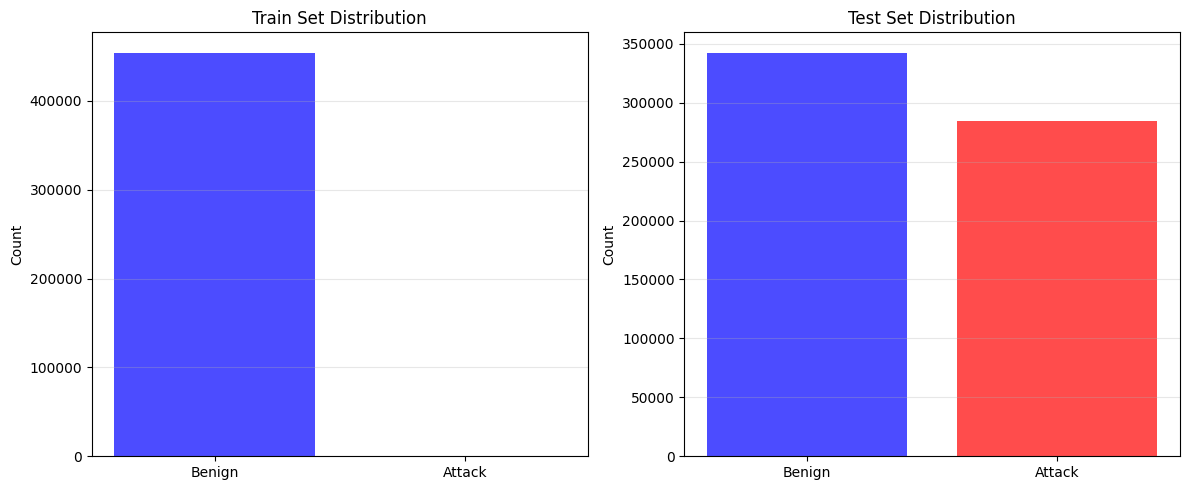

In [11]:
# @title Verifikasi Distribusi Label
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

def count_labels_in_dir(data_dir, set_name="Dataset"):
    files = sorted(glob.glob(str(data_dir / "*.npz")))
    if not files:
        print(f"Tidak ada file di {data_dir}")
        return None, 0

    label_counts = {0: 0, 1: 0}
    total = 0

    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)
                if y is not None:
                    unique, counts = np.unique(y, return_counts=True)
                    for label, count in zip(unique, counts):
                        if label in [0, 1]:
                            label_counts[label] += int(count)
                            total += int(count)
        except Exception as e:
            print(f"Error reading {f}: {e}")

    return label_counts, total

if 'processed_dir' in locals() and processed_dir.exists():
    print("=== Distribusi Label ===")

    train_labels, train_total = count_labels_in_dir(processed_dir / "train", "Train")
    if train_labels:
        print(f"\nTrain Set ({train_total:,} samples):")
        print(f"  Benign (0): {train_labels[0]:,} ({train_labels[0]/train_total*100:.2f}%)")
        print(f"  Attack (1): {train_labels[1]:,} ({train_labels[1]/train_total*100:.2f}%)")
        if train_labels[1] == 0:
            print("  [OK] Train set hanya berisi Benign (sesuai untuk Autoencoder)")

    test_labels, test_total = count_labels_in_dir(processed_dir / "test", "Test")
    if test_labels:
        print(f"\nTest Set ({test_total:,} samples):")
        print(f"  Benign (0): {test_labels[0]:,} ({test_labels[0]/test_total*100:.2f}%)")
        print(f"  Attack (1): {test_labels[1]:,} ({test_labels[1]/test_total*100:.2f}%)")

        if test_labels[0] > 0 and test_labels[1] > 0:
            print("  [OK] Test set berisi kedua kelas (Benign & Attack)")
            imbalance_ratio = test_labels[0] / test_labels[1] if test_labels[1] > 0 else float('inf')
            print(f"  Class Imbalance Ratio: {imbalance_ratio:.2f}")
        else:
            print("  [ERROR] WARNING: Salah satu kelas tidak ada di test set!")

    if train_labels and test_labels:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        ax1.bar(['Benign', 'Attack'], [train_labels[0], train_labels[1]], color=['blue', 'red'], alpha=0.7)
        ax1.set_title('Train Set Distribution')
        ax1.set_ylabel('Count')
        ax1.grid(axis='y', alpha=0.3)

        ax2.bar(['Benign', 'Attack'], [test_labels[0], test_labels[1]], color=['blue', 'red'], alpha=0.7)
        ax2.set_title('Test Set Distribution')
        ax2.set_ylabel('Count')
        ax2.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()
else:
    print("[ERROR] Variable 'processed_dir' tidak ditemukan.")


### 2.4 Data Quality Summary Report
Ringkasan lengkap kualitas data processed untuk review.

In [12]:
# @title Data Quality Summary Report
import numpy as np
import glob

def generate_quality_report(data_dir, set_name="Dataset"):
    files = sorted(glob.glob(str(data_dir / "*.npz")))
    if not files:
        return f"Tidak ada file di {data_dir}"

    report = []
    report.append(f"\n{'='*60}")
    report.append(f"{set_name} Quality Report")
    report.append(f"{'='*60}")
    report.append(f"Total Files: {len(files)}")

    total_samples = 0
    has_nan = False
    has_inf = False
    min_val, max_val = float('inf'), float('-inf')
    shapes = []

    for f in files[:5]:
        try:
            with np.load(f, allow_pickle=True) as data:
                X = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)
                if X is not None:
                    total_samples += len(X)
                    shapes.append(X.shape)

                    if np.isnan(X).any():
                        has_nan = True
                    if np.isinf(X).any():
                        has_inf = True

                    min_val = min(min_val, X.min())
                    max_val = max(max_val, X.max())
        except Exception as e:
            report.append(f"Error: {e}")

    if len(files) > 5:
        avg_samples = total_samples / 5
        total_samples = int(avg_samples * len(files))

    report.append(f"Estimated Total Samples: {total_samples:,}")

    if shapes:
        report.append(f"Sample Shape: {shapes[0]}")
        report.append(f"  - Timesteps: {shapes[0][1]}")
        report.append(f"  - Features: {shapes[0][2]}")

    report.append(f"\nData Range:")
    report.append(f"  Min: {min_val:.6f}, Max: {max_val:.6f}")

    if 0 <= min_val and max_val <= 1:
        report.append(f"  [OK] Data dalam range [0, 1]")
    else:
        report.append(f"  [WARNING] Data di luar range [0, 1]!")

    report.append(f"\nQuality Checks:")
    report.append(f"  NaN: {'[ERROR] FOUND' if has_nan else '[OK] None'}")
    report.append(f"  Inf: {'[ERROR] FOUND' if has_inf else '[OK] None'}")

    return "\n".join(report)

if 'processed_dir' in locals() and processed_dir.exists():
    print(generate_quality_report(processed_dir / "train", "TRAIN SET"))
    print(generate_quality_report(processed_dir / "test", "TEST SET"))

    print(f"\n{'='*60}")
    print("OVERALL ASSESSMENT")
    print(f"{'='*60}")
    print("[OK] Data preprocessing selesai dan siap untuk training")
    print("\nNext Steps:")
    print("  1. Lanjut ke training model")
    print("  2. Monitor training loss dan validation loss")
    print("  3. Evaluate model pada test set")
else:
    print("[ERROR] Variable 'processed_dir' tidak ditemukan.")



TRAIN SET Quality Report
Total Files: 8
Estimated Total Samples: 394,156
Sample Shape: (19536, 10, 34)
  - Timesteps: 10
  - Features: 34

Data Range:
  Min: 0.000000, Max: 1.000000
  [OK] Data dalam range [0, 1]

Quality Checks:
  NaN: [OK] None
  Inf: [OK] None

TEST SET Quality Report
Total Files: 3
Estimated Total Samples: 626,770
Sample Shape: (208949, 10, 34)
  - Timesteps: 10
  - Features: 34

Data Range:
  Min: 0.000000, Max: 1.000000
  [OK] Data dalam range [0, 1]

Quality Checks:
  NaN: [OK] None
  Inf: [OK] None

OVERALL ASSESSMENT
[OK] Data preprocessing selesai dan siap untuk training

Next Steps:
  1. Lanjut ke training model
  2. Monitor training loss dan validation loss
  3. Evaluate model pada test set


## 3. Data Pipeline (Memory Efficient)
Menggunakan `tf.data.Dataset` generator agar hemat RAM.

In [13]:
# @title 1. Data Pipeline (Flexible: Memory Efficient vs Speed Optimized)
# Pilih mode sesuai kapasitas RAM Colab Anda.

# --- KONFIGURASI MODE ---
PIPELINE_MODE = "SPEED_OPTIMIZED"  # Options: "MEMORY_EFFICIENT" (12GB RAM) or "SPEED_OPTIMIZED" (25GB+ RAM)
# -----------------------

import tensorflow as tf
import glob
import numpy as np
import os

print(f"[INFO] Pipeline Mode: {PIPELINE_MODE}")

def npz_generator(files):
    """
    Generator yang membaca file .npz dari list file satu per satu dan yield batch data.
    """
    if not files:
        # print(f"Warning: No files provided") # Silent warning to avoid spam in logs
        return

    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                # Handle keys
                X = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)

                if X is None:
                    continue

                # Yield per sample (tf.data will batch it later)
                for i in range(len(X)):
                    # Autoencoder: Input = Target (X, X)
                    yield X[i], X[i] # Target is X for AE
        except Exception as e:
            print(f"Error reading {f}: {e}")

def create_dataset(files, batch_size=256, shuffle=True, input_shape=None):
    """
    Membuat tf.data.Dataset dari list file shards.
    """
    # Tentukan output signature
    output_signature = (
        tf.TensorSpec(shape=(10, None), dtype=tf.float32), # Input X
        tf.TensorSpec(shape=(10, None), dtype=tf.float32)  # Target X (Autoencoder)
    )

    dataset = tf.data.Dataset.from_generator(
        lambda: npz_generator(files),
        output_signature=output_signature
    )

    # --- LOGIKA MODE ---
    if PIPELINE_MODE == "SPEED_OPTIMIZED":
        # Cache ke RAM setelah pembacaan pertama.
        # Epoch 1: Lambat (Read Disk + Cache). Epoch 2+: Cepat (Read RAM).
        # HATI-HATI: Butuh RAM besar (~20-30GB untuk full dataset)
        dataset = dataset.cache()
        shuffle_buffer = 50000 if shuffle else 1000
    else:
        # Memory Efficient (Streaming)
        # Tidak ada cache, baca disk terus menerus. Hemat RAM tapi lambat.
        shuffle_buffer = 10000 if shuffle else 1000

    if shuffle:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Helper untuk menghitung steps_per_epoch
def count_samples(files):
    total = 0
    if not files:
        print("Warning: No files to count.")
        return 0

    print(f"Counting samples from {len(files)} files...")
    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                key = 'X' if 'X' in data else 'x'
                if key in data:
                    total += data[key].shape[0]
        except: pass
    return total

print("Data Pipeline Ready.")


[INFO] Pipeline Mode: SPEED_OPTIMIZED
Data Pipeline Ready.


## 4. Build & Train Model


⚡ Starting Training Process...
Counting samples from 7 files...
Counting samples from 1 files...
Total Train Samples: 366318
Total Val Samples: 87935
Detected Input Shape: (10, 34)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 34)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 10, 32)         │         3,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 34)         │         6,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,866 (276.82 KB)

 Trainable params: 70,866 (276.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 179s 112ms/step - loss: 0.0794 - val_loss: 0.0597
Epoch 2/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - loss: 0.0496 - val_loss: 0.0498
Epoch 3/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - loss: 0.0431 - val_loss: 0.0415
Epoch 4/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - loss: 0.0385 - val_loss: 0.0362
Epoch 5/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 52s 36ms/step - loss: 0.0352 - val_loss: 0.0334
Epoch 6/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - loss: 0.0333 - val_loss: 0.0318
Epoch 7/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 52s 36ms/step - loss: 0.0319 - val_loss: 0.0306
Epoch 8/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - loss: 0.0310 - val_loss: 0.0296
Epoch 9/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - loss: 0.0303 - val_loss: 0.0289
Epoch 10/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - loss: 0.0296 - val_loss: 0.0284
Epoch 11/50
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - loss: 0.0291 - val_loss: 0.0278
Epoch 

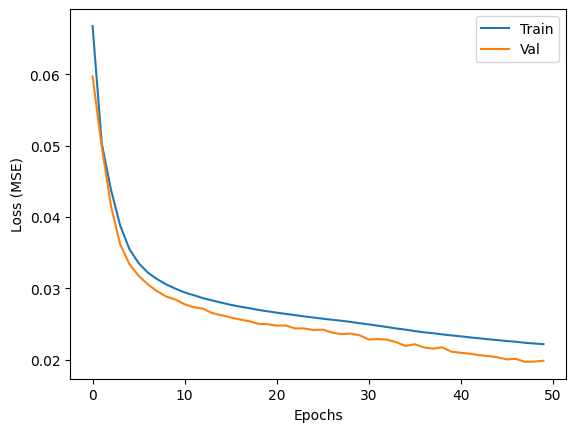

In [14]:
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dropout, Dense, RepeatVector
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Setup Paths & Config
model_save_dir = PROJECT_ROOT / config['paths']['model_save_dir']
model_save_dir.mkdir(parents=True, exist_ok=True)
best_model_path = model_save_dir / "best_model.keras"
final_model_path = model_save_dir / "final_model.keras"

FORCE_RETRAIN = True # Set True to force retrain even if model exists

def build_cnn_lstm_ae(input_shape, encoding_dim=16, learning_rate=0.0005):
    inputs = Input(shape=input_shape)

    # Encoder — CNN feature extraction + LSTM temporal encoding
    conv1 = Conv1D(32, 3, activation='relu', padding='same')(inputs)
    conv2 = Conv1D(64, 3, activation='relu', padding='same')(conv1)
    lstm_enc = LSTM(64, return_sequences=False)(conv2)
    dropout1 = Dropout(0.2)(lstm_enc)
    encoded = Dense(encoding_dim, activation='relu')(dropout1)

    # Decoder — LSTM temporal decoding + CNN reconstruction
    repeat = RepeatVector(input_shape[0])(encoded)
    lstm_dec = LSTM(64, return_sequences=True)(repeat)
    dropout2 = Dropout(0.2)(lstm_dec)
    decoded = Conv1D(input_shape[1], 3, activation='sigmoid', padding='same')(dropout2)

    autoencoder = Model(inputs, decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return autoencoder

# --- LOGIC: LOAD OR TRAIN ---

if not FORCE_RETRAIN and (best_model_path.exists() or final_model_path.exists()):
    print("✅ Pre-trained model found! Loading model...")
    load_path = best_model_path if best_model_path.exists() else final_model_path

    try:
        model = tf.keras.models.load_model(str(load_path))
        print(f"Model loaded from: {load_path}")
        model.summary()

        # We STILL need Validation Data for threshold calculation later
        print("\n[INFO] Loading Validation Data for Threshold Calculation...")
        BATCH_SIZE = config['training']['batch_size']
        if 'train_dir' not in locals():
            train_dir = PROJECT_ROOT / config['paths']['processed_data'] / "train"

        all_files = sorted(glob.glob(str(train_dir / "*.npz")))
        # Use simple split for now just to get val data
        split_idx = int(len(all_files) * (1 - config['training']['validation_split']))
        val_files = all_files[split_idx:]

        if val_files:
            val_ds = create_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False)
            print(f"Validation Dataset Loaded ({len(val_files)} files). Ready for Thresholding.")
        else:
             print("Warning: No validation files found.")

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        print("Falling back to training...")
        FORCE_RETRAIN = True

if FORCE_RETRAIN or ('model' not in locals()):
    print("⚡ Starting Training Process...")

    BATCH_SIZE = config['training']['batch_size']

    # 1. Dataset Setup
    if 'train_dir' not in locals():
        train_dir = PROJECT_ROOT / config['paths']['processed_data'] / "train"

    all_files = sorted(glob.glob(str(train_dir / "*.npz")))
    # Limit number of files used for training if running in light mode
    # all_files = all_files[:10]

    split_idx = int(len(all_files) * (1 - config['training']['validation_split']))
    train_files = all_files[:split_idx]
    val_files = all_files[split_idx:]

    train_samples = count_samples(train_files)
    val_samples = count_samples(val_files)

    print(f"Total Train Samples: {train_samples}")
    print(f"Total Val Samples: {val_samples}")

    if train_samples > 0:
        # Create Datasets
        train_ds = create_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True).repeat()
        val_ds = create_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False)

        train_steps = max(1, train_samples // BATCH_SIZE)
        val_steps = max(1, val_samples // BATCH_SIZE)

        # Build Model
        # Auto-detect input shape
        sample_data = next(iter(train_ds.take(1)))
        input_shape = tuple(sample_data[0].shape[1:])
        print(f"Detected Input Shape: {input_shape}")
        lr = config['model'].get('learning_rate', 0.0005)
        model = build_cnn_lstm_ae(input_shape, encoding_dim=config['model']['encoding_dim'], learning_rate=lr)
        model.summary()

        # Callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=config['training']['patience'], min_delta=config['training'].get('min_delta', 0.0005), restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(str(best_model_path), save_best_only=True, monitor='val_loss')
        ]

        # Fit
        history = model.fit(
            train_ds,
            epochs=config['training']['epochs'],
            steps_per_epoch=train_steps,
            validation_data=val_ds,
            validation_steps=val_steps,
            callbacks=callbacks,
            verbose=1
        )

        model.save(str(final_model_path))
        print(f"Model saved to {final_model_path}")

        # Plot History
        plt.plot(history.history['loss'], label='Train')
        plt.plot(history.history['val_loss'], label='Val')
        plt.xlabel('Epochs')
        plt.ylabel('Loss (MSE)')
        plt.legend()
        plt.show()
    else:
        print("❌ No training data found. Cannot train.")


⚠️ 'cse_ds' not found. Loading small test sample for visualization...
   Loading sample from: /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/test (3 files)
Calculating reconstruction errors...
  - Scanning Validation Set (Benign)...


Val Errors: 0it [00:00, ?it/s]

  - Scanning Test Set Sample (Attack vs Benign)...


Test Errors: 0it [00:00, ?it/s]

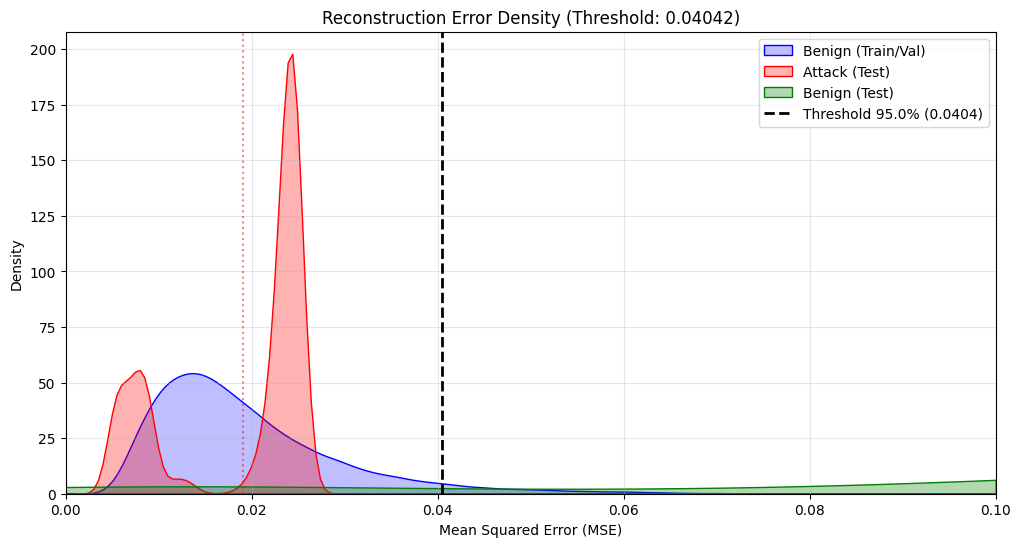


Configuration:
  percentile: 95.0%
  threshold : 0.040418
✅ Threshold set to: 0.040417712181806564


In [15]:
# @title 4.1 Determine Threshold & Visualization (Auto-Load Test Sample)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import tensorflow as tf
from tqdm.notebook import tqdm
import os

# --- Helper to load sample test data if not exists ---
def get_visualization_test_ds(config, project_root, model=None):
    print("⚠️ 'cse_ds' not found. Loading small test sample for visualization...")
    try:
        # Locate Test Files
        test_dir = None
        possible_paths = [
            project_root / config['paths']['processed_data'] / "test",
            project_root / "data/processed/test",
            Path("/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/test")
        ]
        for p in possible_paths:
            if p.exists() and list(p.glob("*.npz")):
                test_dir = p
                break

        if not test_dir:
            print("❌ Could not find Test Data path.")
            return None

        test_files = sorted(glob.glob(str(test_dir / "*.npz")))[:5]
        print(f"   Loading sample from: {test_dir} ({len(test_files)} files)")

        # Generator for (X, y)
        def viz_gen():
            for f in test_files:
                try:
                    with np.load(f, allow_pickle=True) as data:
                        X = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)
                        y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)
                        if X is not None and y is not None:
                            for i in range(len(X)):
                                yield X[i], y[i]
                except Exception:
                    pass

        # Detect input shape from model — FIXED: model di-pass sebagai parameter
        feat_dim = 77
        if model is not None:
            feat_dim = model.input_shape[2]

        output_signature = (
            tf.TensorSpec(shape=(10, feat_dim), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )

        ds = tf.data.Dataset.from_generator(viz_gen, output_signature=output_signature)
        return ds.batch(256).take(200)

    except Exception as e:
        print(f"❌ Error loading test sample: {e}")
        return None


def find_threshold_and_visualize(model, val_ds, test_ds=None, percentile=95):
    print("Calculating reconstruction errors...")

    # 1. Calculate Benign Errors (Validation Set)
    val_errors = []
    print("  - Scanning Validation Set (Benign)...")
    for batch_x, _ in tqdm(val_ds, desc="Val Errors", leave=False):
        recon = model.predict(batch_x, verbose=0)
        mse = np.mean(np.square(batch_x - recon), axis=(1, 2))
        val_errors.extend(mse)
    val_errors = np.array(val_errors)

    # 2. Calculate Test Errors (Mixed) for Viz
    test_errors = []
    test_labels = []

    if test_ds is not None:
        print("  - Scanning Test Set Sample (Attack vs Benign)...")
        for batch_x, batch_y in tqdm(test_ds, desc="Test Errors", leave=False):
            recon = model.predict(batch_x, verbose=0)
            mse = np.mean(np.square(batch_x - recon), axis=(1, 2))
            test_errors.extend(mse)
            test_labels.extend(batch_y.numpy())

        test_errors = np.array(test_errors)
        test_labels = np.array(test_labels)

    # Determine Threshold
    threshold_val = np.percentile(val_errors, percentile)

    # Visualisasi
    plt.figure(figsize=(12, 6))

    sns.kdeplot(val_errors, color='blue', fill=True, label='Benign (Train/Val)', clip=(0, 0.1))

    if len(test_errors) > 0:
        mask_attack = test_labels == 1
        mask_benign_test = test_labels == 0

        if np.any(mask_attack):
            sns.kdeplot(test_errors[mask_attack], color='red', fill=True,
                        label='Attack (Test)', clip=(0, 0.1), alpha=0.3)
            plt.axvline(np.mean(test_errors[mask_attack]), color='red', linestyle=':', alpha=0.5)

        if np.any(mask_benign_test):
            sns.kdeplot(test_errors[mask_benign_test], color='green', fill=True,
                        label='Benign (Test)', clip=(0, 0.1), alpha=0.3)

    plt.axvline(threshold_val, color='black', linestyle='--', linewidth=2,
                label=f'Threshold {percentile}% ({threshold_val:.4f})')

    plt.title(f"Reconstruction Error Density (Threshold: {threshold_val:.5f})")
    plt.xlabel("Mean Squared Error (MSE)")
    plt.xlim(0, 0.1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nConfiguration:")
    print(f"  percentile: {percentile}%")
    print(f"  threshold : {threshold_val:.6f}")

    return threshold_val


# Execute
if 'val_ds' in locals() and 'model' in locals():
    viz_ds = None
    if 'cse_ds' in locals():
        viz_ds = cse_ds.take(200)
    else:
        # FIXED: pass model sebagai argument, bukan pakai locals() di dalam fungsi
        viz_ds = get_visualization_test_ds(config, PROJECT_ROOT, model=model)

    threshold = find_threshold_and_visualize(model, val_ds, test_ds=viz_ds, percentile=config['thresholding']['percentile'])
    print(f"✅ Threshold set to: {threshold}")
else:
    print("❌ Validation dataset (val_ds) or Model not found. Run training first.")

Diagnosing Covariate Shift (Feature Distribution Mismatch)...
--- Loading train Sample ---
  Source: /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/train
  Files : 5
  Loaded Shape: (246348, 10, 34)
--- Loading test Sample ---
  Source: /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/test
  Files : 3
  Loaded Shape: (342591, 10, 34)


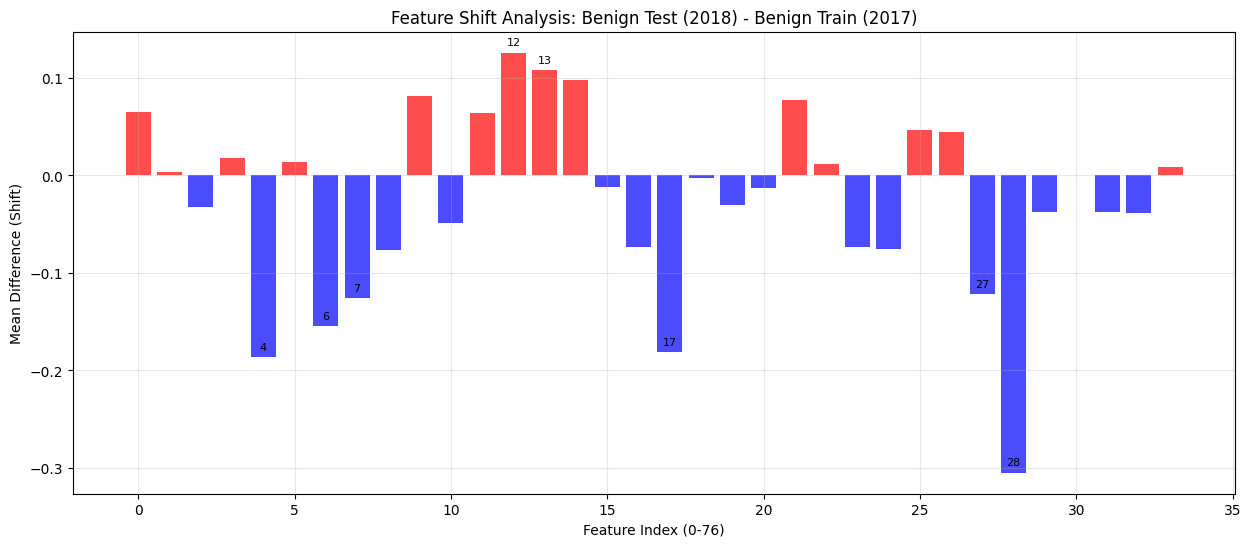


Top 10 Feature Shifts (Significant Drift):
Feat Idx   | Train Mean   | Test Mean    | Delta        | Status
-----------------------------------------------------------------
28         | 0.5028       | 0.1979       | -0.3049      | CRITICAL
4          | 0.4309       | 0.2448       | -0.1861      | Warning
17         | 0.4260       | 0.2443       | -0.1816      | Warning
6          | 0.3969       | 0.2426       | -0.1543      | Warning
7          | 0.5198       | 0.3937       | -0.1262      | Warning
12         | 0.4933       | 0.6191       | +0.1258      | Warning
27         | 0.4606       | 0.3391       | -0.1215      | Warning
13         | 0.2666       | 0.3745       | +0.1079      | Warning
14         | 0.2194       | 0.3168       | +0.0974      | Warning
9          | 0.4904       | 0.5714       | +0.0810      | Warning
21         | 0.2781       | 0.3552       | +0.0771      | Warning
8          | 0.5097       | 0.4330       | -0.0767      | Warning
24         | 0.4357       | 0.36

In [16]:
# @title 4.2 Scientific Diagnosis: Feature Shift Analysis (Robust)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import pandas as pd
from pathlib import Path

def load_data_sample(config, split_name, n_files=5):
    """
    Memuat sampel data secara manual dari disk untuk keperluan diagnosis.
    Menangani path Colab vs Local secara otomatis.
    """
    print(f"--- Loading {split_name} Sample ---")

    # 1. Cari Path
    data_dir = None
    if 'config' in locals():
        candidates = [
            PROJECT_ROOT / config['paths']['processed_data'] / split_name,
            PROJECT_ROOT / "data/processed" / split_name,
            Path(f"/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/{split_name}")
        ]
    else:
        # Fallback hardcoded
        candidates = [
            Path(f"data/processed/{split_name}"),
            Path(f"../data/processed/{split_name}")
        ]

    for p in candidates:
        if p.exists() and list(p.glob("*.npz")):
            data_dir = p
            break

    if not data_dir:
        print(f"❌ Could not find {split_name} data.")
        return None

    # 2. Load Data (X only)
    files = sorted(glob.glob(str(data_dir / "*.npz")))[:n_files]
    print(f"  Source: {data_dir}")
    print(f"  Files : {len(files)}")

    X_list = []
    y_list = []

    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                X_batch = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)
                y_batch = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)

                if X_batch is not None:
                    # Ambil label Benign (0) saja untuk perbandingan Apple-to-Apple
                    # Kita ingin melihat apakah Benign Train vs Benign Test berbeda jauh
                    if y_batch is not None:
                        benign_mask = (y_batch == 0)
                        if np.sum(benign_mask) > 0:
                            X_list.append(X_batch[benign_mask])
                    else:
                        # Jika tidak ada label, ambil semua (asumsi train bersih)
                        X_list.append(X_batch)
        except Exception as e:
            print(f"  Error reading {f}: {e}")

    if X_list:
        X_concat = np.concatenate(X_list, axis=0)
        print(f"  Loaded Shape: {X_concat.shape}")
        return X_concat
    else:
        return None

# --- MAIN DIAGNOSIS ---

# 1. Load Samples (Benign Train vs Benign Test)
print("Diagnosing Covariate Shift (Feature Distribution Mismatch)...")
train_sample = load_data_sample(config if 'config' in locals() else None, "train", n_files=5)
test_sample = load_data_sample(config if 'config' in locals() else None, "test", n_files=5) # CSE-CIC-IDS2018

if train_sample is not None and test_sample is not None:
    # 2. Calculate Statistics per Feature
    # Shape: (samples, time_steps, features) -> Average over samples & time steps
    # Kita ingin melihat statistik per FEATURE (channel 0-76)

    # Rata-rata fitur di seluruh timestep (mean aggregasi)
    train_mean = np.mean(train_sample, axis=(0, 1))
    test_mean = np.mean(test_sample, axis=(0, 1))

    train_min = np.min(train_sample, axis=(0, 1))
    test_min = np.min(test_sample, axis=(0, 1))

    train_max = np.max(train_sample, axis=(0, 1))
    test_max = np.max(test_sample, axis=(0, 1))

    # 3. Calculate Shift
    delta_mean = test_mean - train_mean
    abs_delta = np.abs(delta_mean)

    # 4. Visualization
    features = np.arange(len(train_mean))

    plt.figure(figsize=(15, 6))
    plt.bar(features, delta_mean, color=np.where(delta_mean > 0, 'red', 'blue'), alpha=0.7)
    plt.title("Feature Shift Analysis: Benign Test (2018) - Benign Train (2017)")
    plt.xlabel("Feature Index (0-76)")
    plt.ylabel("Mean Difference (Shift)")
    plt.grid(True, alpha=0.3)

    # Highlight Extreme Shifts
    threshold_shift = 0.1 # Fitur yang bergeser lebih dari 0.1 (mengingat skala 0-1)
    outliers = np.where(abs_delta > threshold_shift)[0]

    for idx in outliers:
        plt.annotate(f"{idx}", (idx, delta_mean[idx]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

    plt.show()

    # 5. Top Drifting Features Report
    print("\nTop 10 Feature Shifts (Significant Drift):")
    # Sort by absolute drift
    sorted_idx = np.argsort(abs_delta)[::-1]

    print(f"{'Feat Idx':<10} | {'Train Mean':<12} | {'Test Mean':<12} | {'Delta':<12} | {'Status'}")
    print("-" * 65)
    for i in range(min(20, len(features))):
        idx = sorted_idx[i]
        diff = delta_mean[idx]
        if abs(diff) > 0.05: # Hanya tampilkan yang signifikan
            status = "CRITICAL" if abs(diff) > 0.2 else "Warning"
            print(f"{idx:<10} | {train_mean[idx]:.4f}       | {test_mean[idx]:.4f}       | {diff:+.4f}      | {status}")

    # 6. Conclusion
    print("\nINTERPRETATION:")
    print("1. Jika Delta positif besar (Red Bars): Data Test nilainya jauh lebih besar dari Train.")
    print("   -> Autoencoder akan menganggap ini anomaly (MSE tinggi).")
    print("2. Jika ini terjadi pada data BENIGN 2018, itulah penyebab False Positive.")
    print("3. Solusi: Kita harus membuang fitur ini atau melakukan Scaling ulang (Domain Adaptation).")

else:
    print("❌ Cannot perform diagnosis. Missing data.")


## 5. Evaluation (Dual-Set)
Evaluasi model pada dua dataset:
1. **CSE-CIC-IDS2018 (Wajib):** Test set utama (Zero-Day Attack).
2. **CIC-IDS2017 (Opsional):** Test set in-domain (jika tersedia).

Set variable `RUN_ALL_EVAL = True` untuk menjalankan keduanya.

In [17]:
# @title 5.1 Shared Evaluation Functions & Setup
# Jalankan cell ini DULU sebelum menjalankan evaluasi di bawah.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import glob
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm.notebook import tqdm
from pathlib import Path

# --- CONFIG: EVALUATION SPEED ---
EVAL_SAMPLE_FRACTION = 0.5  # 0.2 = 20% data (Faster). 1.0 = Full.
# --------------------------------

def evaluate_performance(y_true, y_pred, name='Test Set', color='Blues'):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f'\n[{name}] Performance:')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color)
    plt.title(f'Confusion Matrix ({name})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    return f1

def npz_generator_with_label(files, expected_timesteps=10, expected_feat_dim=77):
    # Generator yield (X[i], y[i]), skip file dengan shape tidak sesuai
    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                X = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)
                y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)
                if X is None or y is None:
                    print(f'[SKIP] {f}: missing X or y key')
                    continue
                if X.ndim != 3:
                    print(f'[SKIP] {f}: X.ndim={X.ndim}, expected 3')
                    continue
                if X.shape[1] != expected_timesteps or X.shape[2] != expected_feat_dim:
                    print(f'[SKIP] {f}: shape {X.shape}, expected (*, {expected_timesteps}, {expected_feat_dim})')
                    continue
                for i in range(len(X)):
                    yield X[i], y[i]
        except Exception as e:
            print(f'[SKIP] {f}: {e}')

def create_eval_dataset(files, batch_size=256, feat_dim=77, timesteps=10):
    # FIXED: feat_dim dan timesteps di-pass eksplisit dari model.input_shape
    # sehingga tidak ada mismatch antara generator dan TensorSpec
    output_signature = (
        tf.TensorSpec(shape=(timesteps, feat_dim), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    dataset = tf.data.Dataset.from_generator(
        lambda: npz_generator_with_label(files, expected_timesteps=timesteps, expected_feat_dim=feat_dim),
        output_signature=output_signature
    )
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def calculate_errors_and_predict(dataset, model, threshold, steps=None):
    all_errors = []
    all_y_true = []
    prog_bar = tqdm(dataset, total=steps, desc='Predicting') if steps else tqdm(dataset, desc='Predicting')
    batch_count = 0
    for batch_x, batch_y in prog_bar:
        recon = model.predict(batch_x, verbose=0)
        mse = np.mean(np.square(batch_x - recon), axis=(1, 2))
        all_errors.extend(mse)
        all_y_true.extend(batch_y.numpy())
        batch_count += 1
        if steps and batch_count >= steps:
            break
    all_errors = np.array(all_errors)
    all_y_true = np.array(all_y_true)
    y_pred = (all_errors > threshold).astype(int)
    return all_y_true, y_pred, all_errors

def count_samples(files):
    total = 0
    if not files: return 0
    check = files[:10]
    for f in check:
        try:
            with np.load(f, allow_pickle=True) as data:
                key = 'X' if 'X' in data else 'x'
                if key in data: total += data[key].shape[0]
        except: pass
    if len(files) > 10:
        avg = total / len(check)
        total = int(avg * len(files))
    return total

print('Evaluation functions ready.')


Evaluation functions ready.


## 5.1 Manual Threshold Configuration
Gunakan cell ini untuk mengatur threshold manual berdasarkan analisa PR Curve sebelumnya.

In [18]:
# @title Threshold Configuration (Auto from Section 4.1)
# Uses the threshold computed by find_threshold_and_visualize() in Section 4.1.
# If PR Curve optimal thresholds are available from Section 5.5, they will be used instead.

if 'threshold' not in locals() or threshold is None:
    print("[WARNING] No threshold found from Section 4.1. Using default 0.05")
    threshold = 0.05

print(f"Active Threshold: {threshold:.6f}")
print(f"  (Source: auto-computed from validation set, percentile={config['thresholding']['percentile']}%)")


Active Threshold: 0.040418
  (Source: auto-computed from validation set, percentile=95.0%)


RUNNING: CSE-CIC-IDS2018 EVALUATION
Using Threshold: 0.040417712181806564
Model expects input shape: (10, 34)

Valid files to evaluate: 3
Found 3 files. Est. Total Samples: 626770
Running FAST EVALUATION on 50% Data.
Processing 1224 batches (approx 313344 samples)...


Predicting:   0%|          | 0/1224 [00:00<?, ?it/s]


[CSE-CIC-IDS2018] Performance:
  Accuracy : 0.6789
  Precision: 0.1837
  Recall   : 0.0439
  F1-Score : 0.0708


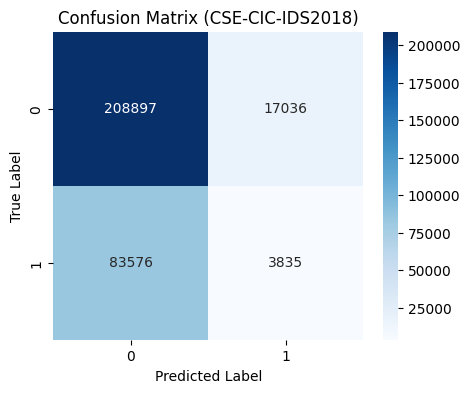

In [19]:
# @title 5.2 EVALUATION: CSE-CIC-IDS2018 (Zero-Day / Cross-Domain)
print('='*40)
print('RUNNING: CSE-CIC-IDS2018 EVALUATION')
print('='*40)

if 'THRESHOLD_CSE' in locals():
    threshold = THRESHOLD_CSE
    print(f'Using Manual Threshold (CSE): {threshold}')
elif 'threshold' not in locals():
    print('Threshold not defined. Using default 0.05')
    threshold = 0.05
else:
    print(f'Using Threshold: {threshold}')

# Detect expected shape langsung dari model — ini sumber kebenaran
EXPECTED_FEAT_DIM  = model.input_shape[2]  # e.g. 77
EXPECTED_TIMESTEPS = model.input_shape[1]  # e.g. 10
print(f'Model expects input shape: ({EXPECTED_TIMESTEPS}, {EXPECTED_FEAT_DIM})')

cse_ds     = None
cse_steps  = None
test_files = []

# Locate files
if 'config' in locals():
    if 'test_data' in config['paths']:
        base_test = PROJECT_ROOT / config['paths']['test_data']
    elif 'processed_data' in config['paths']:
        base_test = PROJECT_ROOT / config['paths']['processed_data'] / 'test'
    else:
        base_test = Path('data/processed/test')
    if base_test.exists():
        test_files = sorted(glob.glob(str(base_test / '*.npz')))

if not test_files:
    candidates = [
        PROJECT_ROOT / 'data/processed/test',
        Path('/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/test'),
        Path('/content/nids-mscnn-bilstm-autoencoder/data/processed/test')
    ]
    for c in candidates:
        if c.exists():
            test_files = sorted(glob.glob(str(c / '*.npz')))
            if test_files: break

# Validasi shape tiap file — skip yang tidak cocok
valid_test_files = []
skipped = []
for f in test_files:
    try:
        with np.load(f, allow_pickle=True) as d:
            X = d['X'] if 'X' in d else d.get('x', None)
            if X is None:
                skipped.append((f, 'No X key found')); continue
            if X.ndim != 3 or X.shape[1] != EXPECTED_TIMESTEPS or X.shape[2] != EXPECTED_FEAT_DIM:
                skipped.append((f, f'Shape mismatch: got {X.shape}, expected (*, {EXPECTED_TIMESTEPS}, {EXPECTED_FEAT_DIM})'))
                continue
            valid_test_files.append(f)
    except Exception as e:
        skipped.append((f, str(e)))

if skipped:
    print(f'\nSkipped {len(skipped)} incompatible file(s):')
    for path, reason in skipped:
        print(f'   - {Path(path).name}: {reason}')

test_files = valid_test_files
print(f'\nValid files to evaluate: {len(test_files)}')

if test_files:
    total_samples = count_samples(test_files)
    BATCH_SIZE    = config['training']['batch_size'] if 'config' in locals() else 256
    full_steps    = max(1, total_samples // BATCH_SIZE)
    cse_steps     = max(1, int(full_steps * EVAL_SAMPLE_FRACTION))

    print(f'Found {len(test_files)} files. Est. Total Samples: {total_samples}')
    print(f'Running FAST EVALUATION on {EVAL_SAMPLE_FRACTION*100:.0f}% Data.')
    print(f'Processing {cse_steps} batches (approx {cse_steps*BATCH_SIZE} samples)...')

    # FIXED: pass feat_dim & timesteps dari model supaya TensorSpec = shape generator
    cse_ds = create_eval_dataset(
        test_files, batch_size=BATCH_SIZE,
        feat_dim=EXPECTED_FEAT_DIM, timesteps=EXPECTED_TIMESTEPS
    )

    y_true_cse, y_pred_cse, errors_cse = calculate_errors_and_predict(cse_ds, model, threshold, cse_steps)
    evaluate_performance(y_true_cse, y_pred_cse, name='CSE-CIC-IDS2018', color='Blues')
else:
    print(f'Tidak ada file valid. Pastikan processed test data punya shape (*, {EXPECTED_TIMESTEPS}, {EXPECTED_FEAT_DIM}).')


RUNNING: CIC-IDS2017 EVALUATION (In-Domain)
Found CIC Test Path at: /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/test_cic
Running FAST EVALUATION on 50% CIC Data.
Processing 1104 batches (approx 282624 samples)...


Predicting:   0%|          | 0/1104 [00:00<?, ?it/s]


[CIC-IDS2017] Performance:
  Accuracy : 0.8371
  Precision: 0.7184
  Recall   : 0.3968
  F1-Score : 0.5112


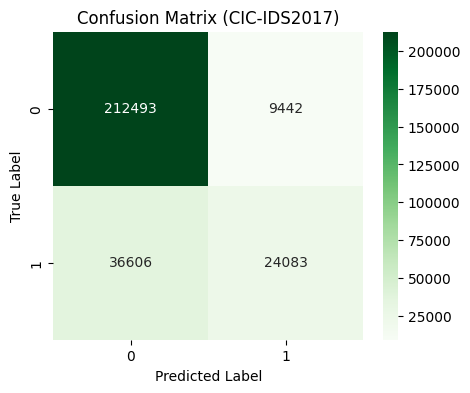

In [20]:
# @title 5.3 EVALUATION: CIC-IDS2017 (In-Domain Reference)
print('\n' + '='*40)
print('RUNNING: CIC-IDS2017 EVALUATION (In-Domain)')
print('='*40)

if 'THRESHOLD_CIC' in locals():
    threshold = THRESHOLD_CIC
    print(f'Using Manual Threshold (CIC): {threshold}')
elif 'threshold' not in locals():
    print('Threshold not defined. Using default 0.05')
    threshold = 0.05

# Detect shape dari model
EXPECTED_FEAT_DIM  = model.input_shape[2]
EXPECTED_TIMESTEPS = model.input_shape[1]

cic_test_path = None
possible_roots = [
    PROJECT_ROOT / 'data' / 'processed',
    Path('/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed'),
    Path('/content/nids-mscnn-bilstm-autoencoder/data/processed')
]
for root in possible_roots:
    candidate = root / 'test_cic'
    if candidate.exists():
        cic_test_path = candidate
        print(f'Found CIC Test Path at: {candidate}')
        break

if cic_test_path:
    cic_files = sorted(glob.glob(str(cic_test_path / '*.npz')))

    # Validasi shape
    valid_cic_files = []
    skipped_cic = []
    for f in cic_files:
        try:
            with np.load(f, allow_pickle=True) as d:
                X = d['X'] if 'X' in d else d.get('x', None)
                if X is None:
                    skipped_cic.append((f, 'No X key')); continue
                if X.ndim != 3 or X.shape[1] != EXPECTED_TIMESTEPS or X.shape[2] != EXPECTED_FEAT_DIM:
                    skipped_cic.append((f, f'Shape mismatch: {X.shape}')); continue
                valid_cic_files.append(f)
        except Exception as e:
            skipped_cic.append((f, str(e)))

    if skipped_cic:
        print(f'Skipped {len(skipped_cic)} CIC file(s) due to shape mismatch.')
    cic_files = valid_cic_files

    if cic_files:
        BATCH_SIZE          = config['training']['batch_size'] if 'config' in locals() else 256
        total_samples_cic   = count_samples(cic_files)
        full_steps_cic      = max(1, total_samples_cic // BATCH_SIZE)
        cic_steps           = max(1, int(full_steps_cic * EVAL_SAMPLE_FRACTION))

        print(f'Running FAST EVALUATION on {EVAL_SAMPLE_FRACTION*100:.0f}% CIC Data.')
        print(f'Processing {cic_steps} batches (approx {cic_steps*BATCH_SIZE} samples)...')

        # FIXED: pass feat_dim & timesteps dari model
        cic_ds = create_eval_dataset(
            cic_files, batch_size=BATCH_SIZE,
            feat_dim=EXPECTED_FEAT_DIM, timesteps=EXPECTED_TIMESTEPS
        )

        y_true_cic, y_pred_cic, errors_cic = calculate_errors_and_predict(cic_ds, model, threshold, cic_steps)
        evaluate_performance(y_true_cic, y_pred_cic, name='CIC-IDS2017', color='Greens')
    else:
        print('CIC Test folder empty atau semua file di-skip karena shape mismatch.')
else:
    print('CIC-IDS2017 Test Data folder test_cic not found. (Wajar jika fokus Cross-Domain)')

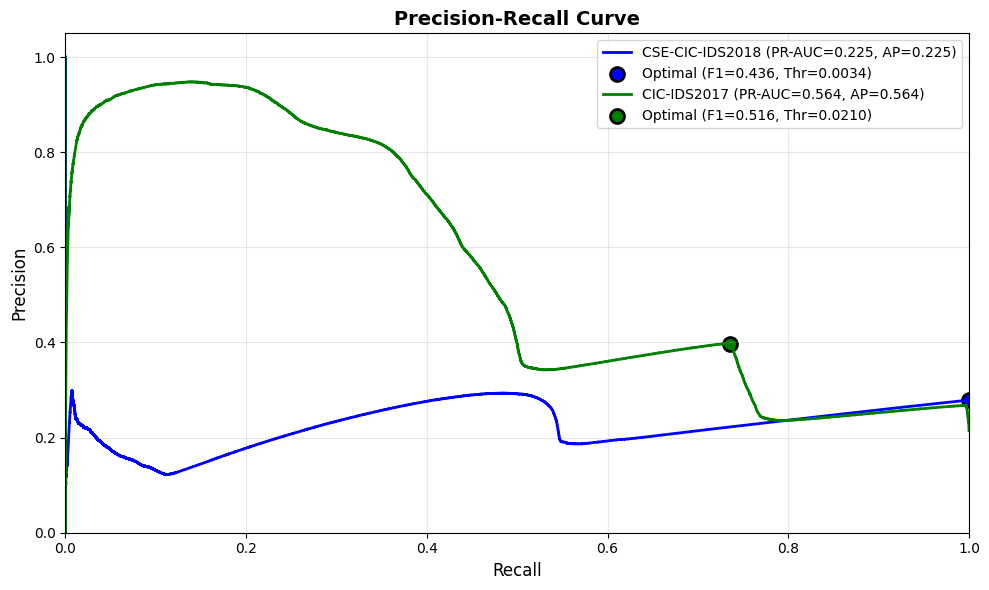


=== Precision-Recall Analysis ===

CSE-CIC-IDS2018:
  PR-AUC: 0.2253
  Average Precision: 0.2253
  Optimal Threshold: 0.003367
  Max F1-Score: 0.4362

CIC-IDS2017:
  PR-AUC: 0.5636
  Average Precision: 0.5636
  Optimal Threshold: 0.021003
  Max F1-Score: 0.5157

[RECOMMENDATION] Optimal threshold untuk maximize F1: 0.003367


In [21]:
# @title 5.4 Precision-Recall Curve Analysis
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

def plot_pr_curve(y_true, errors, threshold, dataset_name="Dataset", color='blue'):
    """Plot Precision-Recall curve dan hitung PR-AUC."""
    # Predictions based on threshold
    y_pred_proba = errors  # Higher error = more likely attack

    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)
    avg_precision = average_precision_score(y_true, y_pred_proba)

    # Find optimal threshold (maximize F1)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else threshold

    # Plot
    plt.plot(recall, precision, color=color, lw=2,
             label=f'{dataset_name} (PR-AUC={pr_auc:.3f}, AP={avg_precision:.3f})')
    plt.scatter(recall[optimal_idx], precision[optimal_idx],
                color=color, s=100, marker='o', edgecolors='black', linewidths=2,
                label=f'Optimal (F1={f1_scores[optimal_idx]:.3f}, Thr={optimal_threshold:.4f})')

    return pr_auc, avg_precision, optimal_threshold, f1_scores[optimal_idx]

# Plot PR Curves
if 'y_true_cse' in locals() and 'errors_cse' in locals():
    plt.figure(figsize=(10, 6))

    # CSE dataset
    pr_auc_cse, ap_cse, opt_thr_cse, f1_cse = plot_pr_curve(
        y_true_cse, errors_cse, threshold, "CSE-CIC-IDS2018", color='blue'
    )

    # CIC dataset (if available)
    if 'y_true_cic' in locals() and 'errors_cic' in locals():
        pr_auc_cic, ap_cic, opt_thr_cic, f1_cic = plot_pr_curve(
            y_true_cic, errors_cic, threshold, "CIC-IDS2017", color='green'
        )

    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.tight_layout()
    plt.show()

    # Print results
    print("\n=== Precision-Recall Analysis ===")
    print(f"\nCSE-CIC-IDS2018:")
    print(f"  PR-AUC: {pr_auc_cse:.4f}")
    print(f"  Average Precision: {ap_cse:.4f}")
    print(f"  Optimal Threshold: {opt_thr_cse:.6f}")
    print(f"  Max F1-Score: {f1_cse:.4f}")

    if 'pr_auc_cic' in locals():
        print(f"\nCIC-IDS2017:")
        print(f"  PR-AUC: {pr_auc_cic:.4f}")
        print(f"  Average Precision: {ap_cic:.4f}")
        print(f"  Optimal Threshold: {opt_thr_cic:.6f}")
        print(f"  Max F1-Score: {f1_cic:.4f}")

    print(f"\n[RECOMMENDATION] Optimal threshold untuk maximize F1: {opt_thr_cse:.6f}")
else:
    print("[ERROR] Evaluation data tidak tersedia. Jalankan cell evaluasi CSE/CIC terlebih dahulu.")


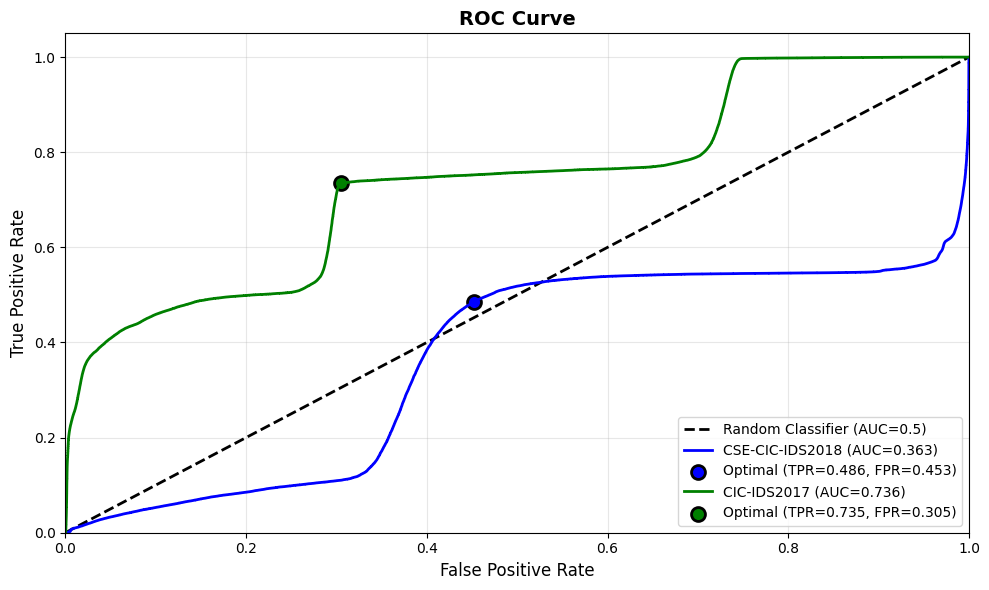


=== ROC Analysis ===

CSE-CIC-IDS2018:
  ROC-AUC: 0.3633
  Optimal Threshold: 0.022348
  TPR at optimal: 0.4859
  FPR at optimal: 0.4526

CIC-IDS2017:
  ROC-AUC: 0.7359
  Optimal Threshold: 0.021001
  TPR at optimal: 0.7351
  FPR at optimal: 0.3051


In [22]:
# @title 5.5 ROC Curve Analysis
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_curve(y_true, errors, dataset_name="Dataset", color='blue'):
    """Plot ROC curve dan hitung ROC-AUC."""
    fpr, tpr, thresholds = roc_curve(y_true, errors)
    roc_auc = roc_auc_score(y_true, errors)

    # Find optimal point (closest to top-left corner)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    optimal_fpr = fpr[optimal_idx]
    optimal_tpr = tpr[optimal_idx]

    # Plot
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{dataset_name} (AUC={roc_auc:.3f})')
    plt.scatter(optimal_fpr, optimal_tpr,
                color=color, s=100, marker='o', edgecolors='black', linewidths=2,
                label=f'Optimal (TPR={optimal_tpr:.3f}, FPR={optimal_fpr:.3f})')

    return roc_auc, optimal_threshold, optimal_tpr, optimal_fpr

# Plot ROC Curves
if 'y_true_cse' in locals() and 'errors_cse' in locals():
    plt.figure(figsize=(10, 6))

    # Baseline (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC=0.5)')

    # CSE dataset
    roc_auc_cse, opt_thr_roc_cse, tpr_cse, fpr_cse = plot_roc_curve(
        y_true_cse, errors_cse, "CSE-CIC-IDS2018", color='blue'
    )

    # CIC dataset (if available)
    if 'y_true_cic' in locals() and 'errors_cic' in locals():
        roc_auc_cic, opt_thr_roc_cic, tpr_cic, fpr_cic = plot_roc_curve(
            y_true_cic, errors_cic, "CIC-IDS2017", color='green'
        )

    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.tight_layout()
    plt.show()

    # Print results
    print("\n=== ROC Analysis ===")
    print(f"\nCSE-CIC-IDS2018:")
    print(f"  ROC-AUC: {roc_auc_cse:.4f}")
    print(f"  Optimal Threshold: {opt_thr_roc_cse:.6f}")
    print(f"  TPR at optimal: {tpr_cse:.4f}")
    print(f"  FPR at optimal: {fpr_cse:.4f}")

    if 'roc_auc_cic' in locals():
        print(f"\nCIC-IDS2017:")
        print(f"  ROC-AUC: {roc_auc_cic:.4f}")
        print(f"  Optimal Threshold: {opt_thr_roc_cic:.6f}")
        print(f"  TPR at optimal: {tpr_cic:.4f}")
        print(f"  FPR at optimal: {fpr_cic:.4f}")
else:
    print("[ERROR] Evaluation data tidak tersedia.")


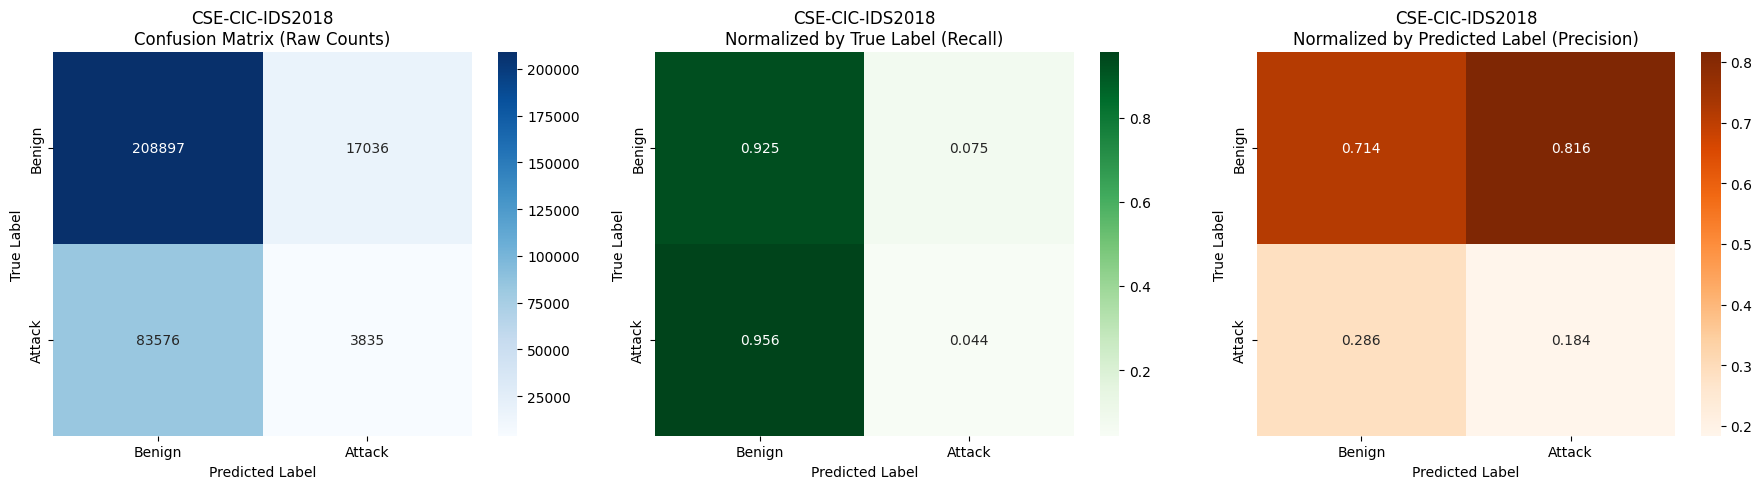


=== Detailed Metrics for CSE-CIC-IDS2018 ===

Confusion Matrix:
  True Negative (TN): 208,897
  False Positive (FP): 17,036
  False Negative (FN): 83,576
  True Positive (TP): 3,835

Rates:
  True Positive Rate (TPR/Recall/Sensitivity): 0.0439
  True Negative Rate (TNR/Specificity): 0.9246
  False Positive Rate (FPR): 0.0754
  False Negative Rate (FNR): 0.9561

Predictive Values:
  Positive Predictive Value (PPV/Precision): 0.1837
  Negative Predictive Value (NPV): 0.7142


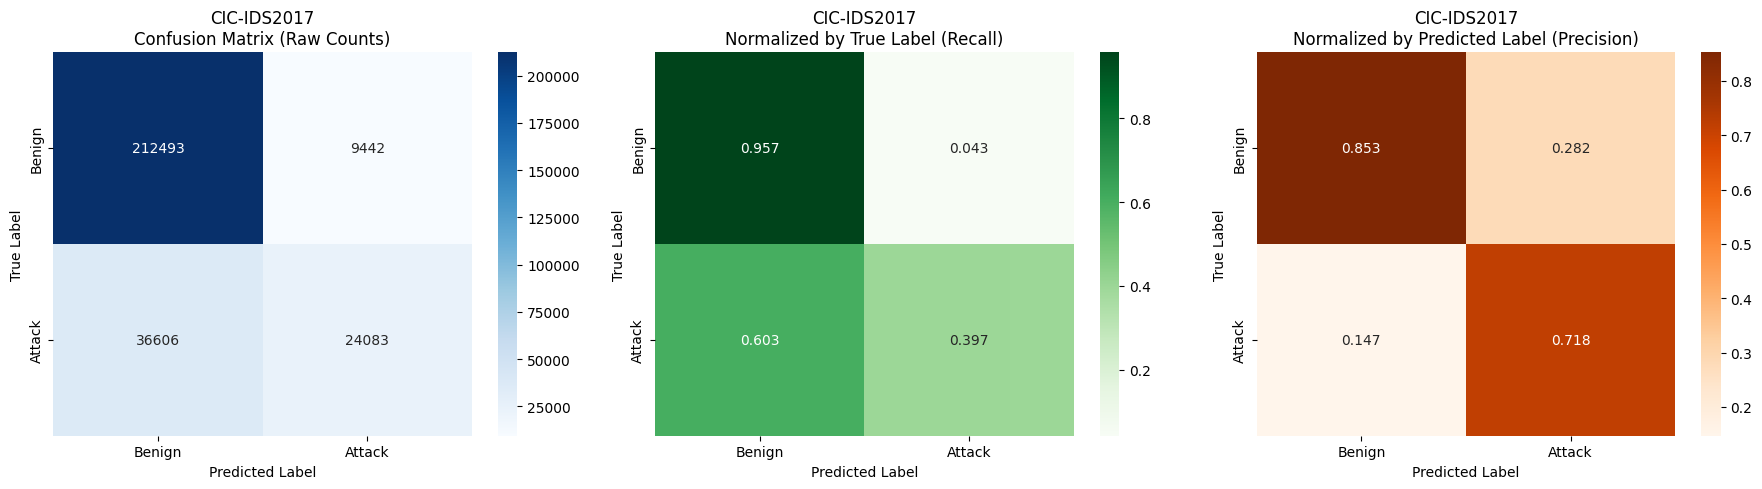


=== Detailed Metrics for CIC-IDS2017 ===

Confusion Matrix:
  True Negative (TN): 212,493
  False Positive (FP): 9,442
  False Negative (FN): 36,606
  True Positive (TP): 24,083

Rates:
  True Positive Rate (TPR/Recall/Sensitivity): 0.3968
  True Negative Rate (TNR/Specificity): 0.9575
  False Positive Rate (FPR): 0.0425
  False Negative Rate (FNR): 0.6032

Predictive Values:
  Positive Predictive Value (PPV/Precision): 0.7184
  Negative Predictive Value (NPV): 0.8530


In [23]:
# @title 5.6 Advanced Confusion Matrix dengan Normalized Values
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_advanced_confusion_matrix(y_true, y_pred, dataset_name="Dataset"):
    """Plot confusion matrix dengan berbagai normalisasi."""
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized_true = confusion_matrix(y_true, y_pred, normalize='true')
    cm_normalized_pred = confusion_matrix(y_true, y_pred, normalize='pred')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
    axes[0].set_title(f'{dataset_name}\nConfusion Matrix (Raw Counts)')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # Normalized by true label (Recall)
    sns.heatmap(cm_normalized_true, annot=True, fmt='.3f', cmap='Greens', ax=axes[1],
                xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
    axes[1].set_title(f'{dataset_name}\nNormalized by True Label (Recall)')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    # Normalized by predicted label (Precision)
    sns.heatmap(cm_normalized_pred, annot=True, fmt='.3f', cmap='Oranges', ax=axes[2],
                xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
    axes[2].set_title(f'{dataset_name}\nNormalized by Predicted Label (Precision)')
    axes[2].set_ylabel('True Label')
    axes[2].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

    # Detailed metrics
    TN, FP, FN, TP = cm.ravel()
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # Recall / Sensitivity
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0  # Specificity
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # False Positive Rate
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0  # False Negative Rate
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0  # Precision
    NPV = TN / (TN + FN) if (TN + FN) > 0 else 0  # Negative Predictive Value

    print(f"\n=== Detailed Metrics for {dataset_name} ===")
    print(f"\nConfusion Matrix:")
    print(f"  True Negative (TN): {TN:,}")
    print(f"  False Positive (FP): {FP:,}")
    print(f"  False Negative (FN): {FN:,}")
    print(f"  True Positive (TP): {TP:,}")
    print(f"\nRates:")
    print(f"  True Positive Rate (TPR/Recall/Sensitivity): {TPR:.4f}")
    print(f"  True Negative Rate (TNR/Specificity): {TNR:.4f}")
    print(f"  False Positive Rate (FPR): {FPR:.4f}")
    print(f"  False Negative Rate (FNR): {FNR:.4f}")
    print(f"\nPredictive Values:")
    print(f"  Positive Predictive Value (PPV/Precision): {PPV:.4f}")
    print(f"  Negative Predictive Value (NPV): {NPV:.4f}")

    return cm, TPR, FPR, PPV

# Plot for CSE
if 'y_true_cse' in locals() and 'y_pred_cse' in locals():
    cm_cse, tpr_cse, fpr_cse, ppv_cse = plot_advanced_confusion_matrix(
        y_true_cse, y_pred_cse, "CSE-CIC-IDS2018"
    )

    # Plot for CIC if available
    if 'y_true_cic' in locals() and 'y_pred_cic' in locals():
        cm_cic, tpr_cic, fpr_cic, ppv_cic = plot_advanced_confusion_matrix(
            y_true_cic, y_pred_cic, "CIC-IDS2017"
        )
else:
    print("[ERROR] Prediction data tidak tersedia.")


=== Threshold Tuning for CSE-CIC-IDS2018 ===


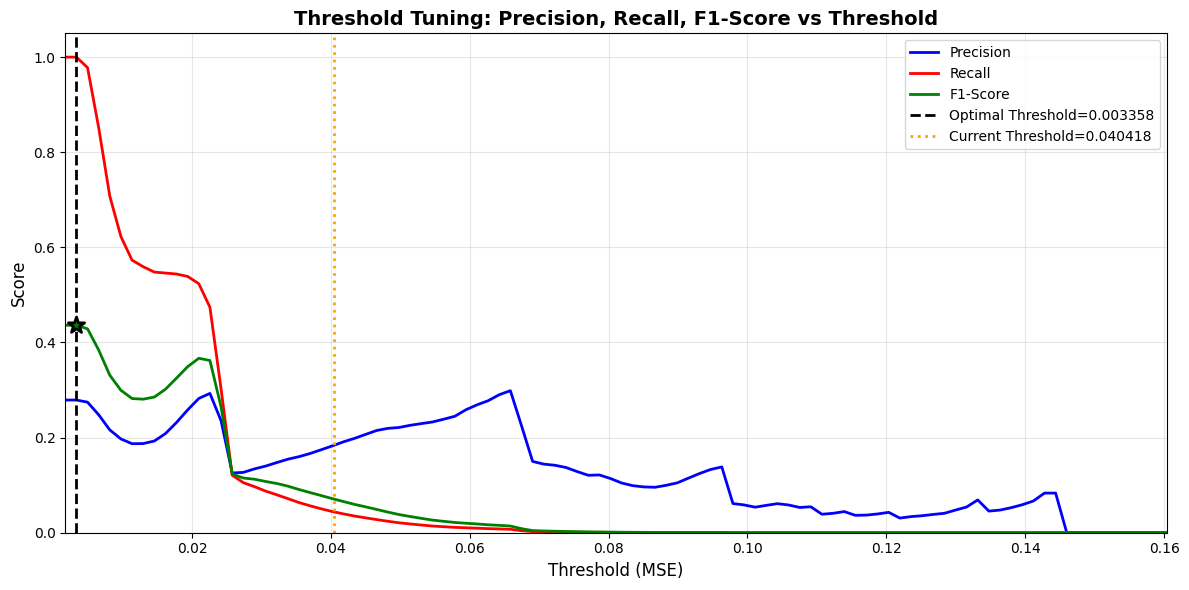


Optimal Threshold: 0.003358
  F1-Score: 0.4362
  Precision: 0.2790
  Recall: 1.0000

Current Threshold: 0.040418
  F1-Score: 0.0708

[RECOMMENDATION] Optimal threshold dapat meningkatkan F1 sebesar 515.86%


In [24]:
# @title 5.7 Threshold Tuning Explorer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

def explore_thresholds(y_true, errors, threshold_range=None):
    """Explore different thresholds dan plot metrics."""
    if threshold_range is None:
        # Auto range berdasarkan distribusi error
        min_err, max_err = errors.min(), errors.max()
        threshold_range = np.linspace(min_err, max_err, 100)

    precisions = []
    recalls = []
    f1_scores = []

    for thr in threshold_range:
        y_pred = (errors > thr).astype(int)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)

    # Find optimal threshold
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = threshold_range[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]
    optimal_prec = precisions[optimal_idx]
    optimal_rec = recalls[optimal_idx]

    return threshold_range, precisions, recalls, f1_scores, optimal_threshold, optimal_f1, optimal_prec, optimal_rec

# Threshold exploration for CSE
if 'y_true_cse' in locals() and 'errors_cse' in locals():
    print("=== Threshold Tuning for CSE-CIC-IDS2018 ===")

    thresholds, precs, recs, f1s, opt_thr, opt_f1, opt_prec, opt_rec = explore_thresholds(
        y_true_cse, errors_cse
    )

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(thresholds, precs, 'b-', label='Precision', linewidth=2)
    plt.plot(thresholds, recs, 'r-', label='Recall', linewidth=2)
    plt.plot(thresholds, f1s, 'g-', label='F1-Score', linewidth=2)
    plt.axvline(opt_thr, color='black', linestyle='--', linewidth=2, label=f'Optimal Threshold={opt_thr:.6f}')
    plt.scatter(opt_thr, opt_f1, color='green', s=150, marker='*', edgecolors='black', linewidths=2, zorder=5)

    if 'threshold' in locals():
        plt.axvline(threshold, color='orange', linestyle=':', linewidth=2, label=f'Current Threshold={threshold:.6f}')

    plt.xlabel('Threshold (MSE)', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title('Threshold Tuning: Precision, Recall, F1-Score vs Threshold', fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.xlim([thresholds.min(), min(thresholds.max(), 0.2)])  # Zoom ke range relevan
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()

    print(f"\nOptimal Threshold: {opt_thr:.6f}")
    print(f"  F1-Score: {opt_f1:.4f}")
    print(f"  Precision: {opt_prec:.4f}")
    print(f"  Recall: {opt_rec:.4f}")

    if 'threshold' in locals():
        print(f"\nCurrent Threshold: {threshold:.6f}")
        y_pred_current = (errors_cse > threshold).astype(int)
        current_f1 = f1_score(y_true_cse, y_pred_current, zero_division=0)
        print(f"  F1-Score: {current_f1:.4f}")

        if opt_f1 > current_f1:
            improvement = ((opt_f1 - current_f1) / current_f1) * 100
            print(f"\n[RECOMMENDATION] Optimal threshold dapat meningkatkan F1 sebesar {improvement:.2f}%")
else:
    print("[ERROR] Evaluation data tidak tersedia.")


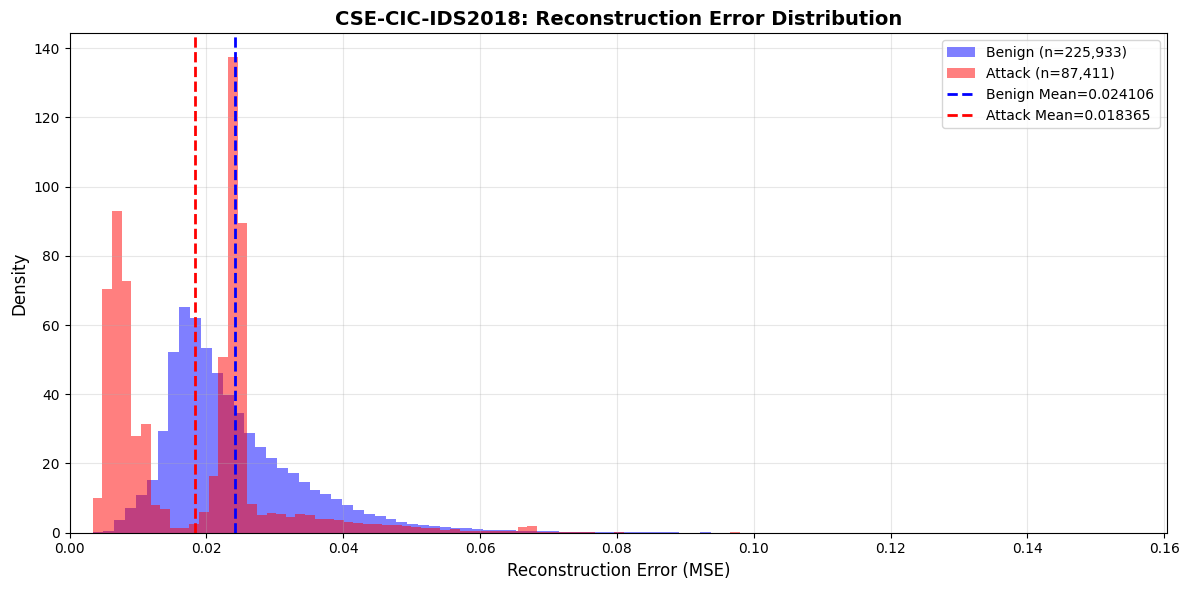


=== Reconstruction Error Analysis: CSE-CIC-IDS2018 ===

Benign Errors:
  Count: 225,933
  Mean: 0.024106
  Median: 0.021288
  Std: 0.010743
  Min: 0.001756, Max: 0.160400

Attack Errors:
  Count: 87,411
  Mean: 0.018365
  Median: 0.021973
  Std: 0.011728
  Min: 0.003367, Max: 0.144544

Separability Test (Kolmogorov-Smirnov):
  KS Statistic: 0.3901
  P-value: 0.000000
  [OK] Distribusi sangat berbeda (p < 0.001) - Model dapat membedakan dengan baik!


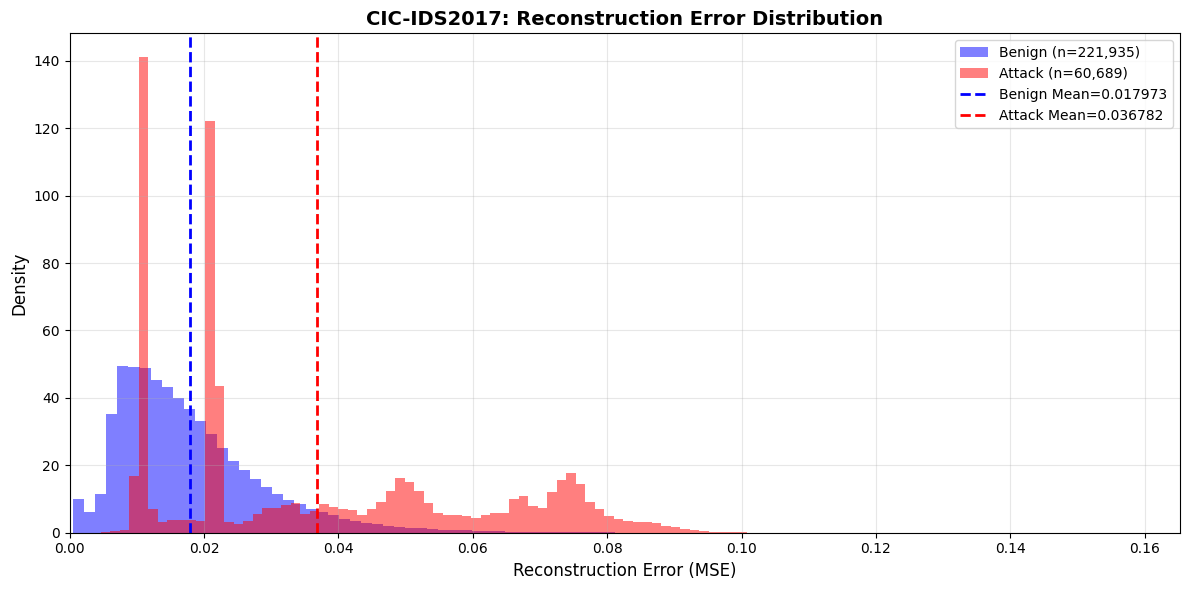


=== Reconstruction Error Analysis: CIC-IDS2017 ===

Benign Errors:
  Count: 221,935
  Mean: 0.017973
  Median: 0.015549
  Std: 0.011070
  Min: 0.000516, Max: 0.165257

Attack Errors:
  Count: 60,689
  Mean: 0.036782
  Median: 0.024957
  Std: 0.024215
  Min: 0.003239, Max: 0.144593

Separability Test (Kolmogorov-Smirnov):
  KS Statistic: 0.4300
  P-value: 0.000000
  [OK] Distribusi sangat berbeda (p < 0.001) - Model dapat membedakan dengan baik!


In [25]:
# @title 5.8 Reconstruction Error Distribution Analysis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

def analyze_reconstruction_errors(y_true, errors, dataset_name="Dataset"):
    """Analisis distribusi reconstruction error untuk benign vs attack."""
    # Separate by label
    benign_errors = errors[y_true == 0]
    attack_errors = errors[y_true == 1]

    # Statistical test
    ks_statistic, p_value = ks_2samp(benign_errors, attack_errors)

    # Plot distributions
    plt.figure(figsize=(12, 6))

    # Histogram
    plt.hist(benign_errors, bins=100, alpha=0.5, label=f'Benign (n={len(benign_errors):,})',
             density=True, color='blue')
    plt.hist(attack_errors, bins=100, alpha=0.5, label=f'Attack (n={len(attack_errors):,})',
             density=True, color='red')

    # Add mean lines
    plt.axvline(benign_errors.mean(), color='blue', linestyle='--', linewidth=2,
                label=f'Benign Mean={benign_errors.mean():.6f}')
    plt.axvline(attack_errors.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Attack Mean={attack_errors.mean():.6f}')

    # Add threshold if available
    if 'threshold' in locals():
        plt.axvline(threshold, color='black', linestyle='-', linewidth=2,
                    label=f'Threshold={threshold:.6f}')

    plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title(f'{dataset_name}: Reconstruction Error Distribution', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.xlim([0, min(0.2, errors.max())])  # Zoom ke range relevan
    plt.tight_layout()
    plt.show()

    # Statistics
    print(f"\n=== Reconstruction Error Analysis: {dataset_name} ===")
    print(f"\nBenign Errors:")
    print(f"  Count: {len(benign_errors):,}")
    print(f"  Mean: {benign_errors.mean():.6f}")
    print(f"  Median: {np.median(benign_errors):.6f}")
    print(f"  Std: {benign_errors.std():.6f}")
    print(f"  Min: {benign_errors.min():.6f}, Max: {benign_errors.max():.6f}")

    print(f"\nAttack Errors:")
    print(f"  Count: {len(attack_errors):,}")
    print(f"  Mean: {attack_errors.mean():.6f}")
    print(f"  Median: {np.median(attack_errors):.6f}")
    print(f"  Std: {attack_errors.std():.6f}")
    print(f"  Min: {attack_errors.min():.6f}, Max: {attack_errors.max():.6f}")

    print(f"\nSeparability Test (Kolmogorov-Smirnov):")
    print(f"  KS Statistic: {ks_statistic:.4f}")
    print(f"  P-value: {p_value:.6f}")

    if p_value < 0.001:
        print("  [OK] Distribusi sangat berbeda (p < 0.001) - Model dapat membedakan dengan baik!")
    elif p_value < 0.05:
        print("  [OK] Distribusi berbeda signifikan (p < 0.05)")
    else:
        print("  [WARNING] Distribusi tidak cukup berbeda - Model kesulitan membedakan!")

    # Error analysis - find misclassified samples
    if 'threshold' in locals():
        y_pred = (errors > threshold).astype(int)

        # False Positives (Benign diprediksi Attack)
        fp_mask = (y_true == 0) & (y_pred == 1)
        fp_errors = errors[fp_mask]

        # False Negatives (Attack diprediksi Benign)
        fn_mask = (y_true == 1) & (y_pred == 0)
        fn_errors = errors[fn_mask]

        print(f"\nMisclassification Analysis (Threshold={threshold:.6f}):")
        print(f"  False Positives: {len(fp_errors):,}")
        if len(fp_errors) > 0:
            print(f"    Mean Error: {fp_errors.mean():.6f}")
            print(f"    These benign samples have high reconstruction error.")

        print(f"  False Negatives: {len(fn_errors):,}")
        if len(fn_errors) > 0:
            print(f"    Mean Error: {fn_errors.mean():.6f}")
            print(f"    These attacks have low reconstruction error (harder to detect).")

    return benign_errors, attack_errors, ks_statistic, p_value

# Analyze CSE
if 'y_true_cse' in locals() and 'errors_cse' in locals():
    benign_err_cse, attack_err_cse, ks_cse, p_cse = analyze_reconstruction_errors(
        y_true_cse, errors_cse, "CSE-CIC-IDS2018"
    )

    # Analyze CIC if available
    if 'y_true_cic' in locals() and 'errors_cic' in locals():
        benign_err_cic, attack_err_cic, ks_cic, p_cic = analyze_reconstruction_errors(
            y_true_cic, errors_cic, "CIC-IDS2017"
        )
else:
    print("[ERROR] Evaluation data tidak tersedia.")


## 6. Comprehensive Experiment Summary & Review
Ringkasan lengkap hasil eksperimen untuk evaluasi mandiri dan reviewer.
Mencakup metrik kunci, interpretasi performa, dan catatan anomali.

In [26]:
# @title Performance Comparison (Visual Summary)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_performance_summary():
    data = []

    # Collect CSE Results
    if 'y_true_cse' in locals() and 'y_pred_cse' in locals():
        acc_cse = accuracy_score(y_true_cse, y_pred_cse)
        rec_cse = recall_score(y_true_cse, y_pred_cse, zero_division=0)
        prec_cse = precision_score(y_true_cse, y_pred_cse, zero_division=0)
        f1_cse = f1_score(y_true_cse, y_pred_cse, zero_division=0)
        data.extend([
            {'Dataset': 'CSE-CIC-IDS2018 (Zero-Day)', 'Metric': 'Accuracy', 'Value': acc_cse},
            {'Dataset': 'CSE-CIC-IDS2018 (Zero-Day)', 'Metric': 'Recall', 'Value': rec_cse},
            {'Dataset': 'CSE-CIC-IDS2018 (Zero-Day)', 'Metric': 'Precision', 'Value': prec_cse},
            {'Dataset': 'CSE-CIC-IDS2018 (Zero-Day)', 'Metric': 'F1-Score', 'Value': f1_cse},
        ])

    # Collect CIC Results
    if 'y_true_cic' in locals() and 'y_pred_cic' in locals():
        acc_cic = accuracy_score(y_true_cic, y_pred_cic)
        rec_cic = recall_score(y_true_cic, y_pred_cic, zero_division=0)
        prec_cic = precision_score(y_true_cic, y_pred_cic, zero_division=0)
        f1_cic = f1_score(y_true_cic, y_pred_cic, zero_division=0)
        data.extend([
            {'Dataset': 'CIC-IDS2017 (In-Domain)', 'Metric': 'Accuracy', 'Value': acc_cic},
            {'Dataset': 'CIC-IDS2017 (In-Domain)', 'Metric': 'Recall', 'Value': rec_cic},
            {'Dataset': 'CIC-IDS2017 (In-Domain)', 'Metric': 'Precision', 'Value': prec_cic},
            {'Dataset': 'CIC-IDS2017 (In-Domain)', 'Metric': 'F1-Score', 'Value': f1_cic},
        ])

    if not data:
        print("No evaluation results found to plot.")
        return

    df_summary = pd.DataFrame(data)

    # Plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_summary, x='Metric', y='Value', hue='Dataset', palette='viridis')
    plt.title('Performance Comparison: Zero-Day vs In-Domain')
    plt.ylim(0, 1.1)
    plt.ylabel('Score')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Add values on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

    plt.legend(loc='lower right')
    plt.show()

plot_performance_summary()


No evaluation results found to plot.
